# Análisis EDA y Clasificación de Tickets de Incidentes Bancarios

Este notebook realiza un análisis exploratorio de datos (EDA) y un modelo de clasificación para predecir la categoría de cada ticket de incidentes bancarios a partir de un archivo CSV.

## 1. Carga de Librerías y Configuración Inicial

In [3]:
# ── Librería estándar ─────────────────────────────────────────────────────────
import os
import re
import unicodedata
import warnings
from collections import Counter

# ── Datos y visualización ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ── Procesamiento de texto ────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords

# ── Estadística y matrices dispersas ─────────────────────────────────────────
from scipy.stats import f_oneway
from scipy.sparse import vstack

# ── Scikit-learn: features y preprocesamiento ────────────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Scikit-learn: modelos ─────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-learn: selección de modelos y métricas ────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)

# ── Imbalanced-learn ─────────────────────────────────────────────────────────
from imblearn.over_sampling import RandomOverSampler

warnings.filterwarnings('ignore')

# ── Configuración de gráficos ─────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (10, 6)})


## 2. Carga y Exploración Inicial de Datos

In [4]:
# Cargar el archivo CSV
# Ruta relativa desde Analisis/ hacia Data/ (un nivel arriba)
ruta_csv = "../Datos/IncidentesCategorizados_v2.csv"
print('Directorio actual:', os.getcwd())
print('Ruta CSV:', ruta_csv)

# Intenta cargar el archivo
try:
    try:
        df = pd.read_csv(ruta_csv, sep=",", encoding="latin-1")
        if len(df.columns) == 1:
            raise ValueError("Wrong delimiter")
    except (ValueError, pd.errors.ParserError):
        df = pd.read_csv(ruta_csv, sep=";", encoding="latin-1")
except FileNotFoundError as e:
    print('No se encontró el archivo. Verifica la ruta y ubicación.')
    raise e

# Mostrar primeras filas y resumen
print('Dimensiones:', df.shape)
df.head()


Directorio actual: z:\Deberes\Maestrías\Inteligencia Artificial Aplicada\Proyecto Integrador\Asignador\Incidentes\Entrenamiento\Semisupervisado
Ruta CSV: ../Datos/IncidentesCategorizados_v2.csv
Dimensiones: (7556, 30)


,number,state,sys_created_on,category,u_subcategory,u_subcategory_2,contact_type,business_duration,cmdb_ci_business_app,cmdb_ci,...,location.cmn_location_type,assignment_group,assigned_to,description,comments_and_work_notes,resolved_at,close_notes,u_categoria_error,u_subcategoria_error,Categoría
0,INC0755414,Nuevo,19/02/2026 16:30:59,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0.0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,NANCY CECILIA NASIMBA CHALCO,segun ticket ingresado RITM0800991 me sugiere...,NaN,NaN,NaN,NaN,NaN,Activos
1,INC0754016,Nuevo,18/02/2026 23:00:43,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0.0,Bancs,NaN,...,Edificio/Estructura,TEC_TCS_N1_RYR_APLICACIONES,LUISA VERONICA MORENO LEMA,CON FECHA 22 DE ENERO 2026 LAS OPERACIONES 800...,NaN,NaN,NaN,NaN,NaN,Activos
2,INC0754538,Nuevo,19/02/2026 09:55:17,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,Self Service,0.0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,LUISA VERONICA MORENO LEMA,"Favor su apoyo, revisando el abono al capital,...",NaN,NaN,NaN,NaN,NaN,Activos
3,INC0753295,Nuevo,18/02/2026 14:30:54,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0.0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,LUISA VERONICA MORENO LEMA,por favor su ayuda con la regularización para ...,18/02/2026 17:35:05 - JOAO CRISTOFFER PEREZ PA...,NaN,NaN,NaN,NaN,Activos
4,INC0756601,Nuevo,20/02/2026 10:46:17,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,Self Service,0.0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,LEONELA JACKELINE DELGADO MENDIETA,su gentil ayuda con el siguiente caso la clien...,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Tipos de datos y valores nulos
df.info()
df.isnull().sum().sort_values(ascending=False).head(15)

<class 'pandas.DataFrame'>
RangeIndex: 7556 entries, 0 to 7555
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   number                      7556 non-null   str    
 1   state                       7556 non-null   str    
 2   sys_created_on              7556 non-null   str    
 3   category                    7556 non-null   str    
 4   u_subcategory               7556 non-null   str    
 5   u_subcategory_2             7556 non-null   str    
 6   contact_type                7556 non-null   str    
 7   business_duration           7354 non-null   float64
 8   cmdb_ci_business_app        4792 non-null   str    
 9   cmdb_ci                     2530 non-null   str    
 10  short_description           7556 non-null   str    
 11  priority                    7556 non-null   str    
 12  severity                    7556 non-null   str    
 13  caller_id                   7556 non-null   

cmdb_ci                       5026
cmdb_ci_business_app          2764
comments_and_work_notes       1608
u_categoria_error              841
u_subcategoria_error           733
location.cmn_location_type     587
location                       587
Categoría                      313
resolved_at                    229
close_notes                    228
business_duration              202
u_affected_user.department     117
assigned_to                     37
description                      5
u_affected_user.title            4
dtype: int64

In [6]:
# Exploración rápida de variables informativas
print('\nPorcentaje de valores nulos por columna:')
print((df.isnull().mean()*100).sort_values(ascending=False))
print('\nNúmero de valores únicos por columna:')
print(df.nunique().sort_values(ascending=False))

# Sugerencia de variables informativas (no ID, no columnas vacías o con un solo valor)
columnas_informativas = [col for col in df.columns if df[col].nunique()>1 and df[col].nunique()<df.shape[0]*0.9 and not col.lower().startswith('id')]
print('\nColumnas potencialmente informativas:')
print(columnas_informativas)



Porcentaje de valores nulos por columna:
cmdb_ci                       66.516675
cmdb_ci_business_app          36.580201
comments_and_work_notes       21.281101
u_categoria_error             11.130228
u_subcategoria_error           9.700900
location.cmn_location_type     7.768661
location                       7.768661
Categoría                      4.142403
resolved_at                    3.030704
close_notes                    3.017470
business_duration              2.673372
u_affected_user.department     1.548438
assigned_to                    0.489677
description                    0.066173
u_affected_user.title          0.052938
u_affected_user.company        0.052938
u_affected_user                0.052938
priority                       0.000000
caller_id                      0.000000
severity                       0.000000
u_subcategory                  0.000000
u_subcategory_2                0.000000
state                          0.000000
number                         0.00000

number                        7549
sys_created_on                7548
resolved_at                   7322
description                   7250
short_description             7148
business_duration             6176
comments_and_work_notes       5946
close_notes                   5882
u_affected_user               1932
caller_id                     1884
location                       252
u_affected_user.title          171
u_subcategoria_error           142
u_affected_user.department      61
Categoría                       31
assigned_to                     31
u_subcategory_2                 24
cmdb_ci                         18
cmdb_ci_business_app            17
u_affected_user.company         16
u_categoria_error               12
u_subcategory                   12
category                         7
state                            5
contact_type                     5
severity                         4
reopen_count                     3
assignment_group                 3
location.cmn_locatio

## 3. Limpieza y Preprocesamiento de Datos

## 3.1 Columna Clasificación

In [7]:
# Cambiar el nombre de la columna 'Categoria' por 'Clasificación'
df = df.rename(columns={"Categoría": "Clasificación"})

In [8]:
# Mostrar la distribución de clases (conteo de tickets por clasificación)
conteo_clases = df['Clasificación'].value_counts(dropna=False)
print(conteo_clases)

Clasificación
0                         3366
BancsLink                  792
Activos                    568
Cuentas                    452
Inversiones                378
Pendiente                  327
NaN                        313
Contabilidad               229
Formas numeradas           183
Chequeras                  158
Cheques                    144
SISREP                     136
Reportes Batch              84
Estados de cuenta           69
No productivo               54
Garantías                   54
Retenciones Judiciales      40
No aplica                   39
Clientes                    39
Firmas autorizadas          33
Incidencias                 17
BNC_CLIENTES                16
Cartola                     15
Sobregiros                  11
Formas Numeradas            11
Firmas Autorizadas           9
CNBs                         6
MT940                        4
Trickle Feed                 4
Cuentas                      2
CC-Cancelación batch         2
CC-Evento/alerta         

In [9]:
# Revisar valores únicos y nulos en 'Clasificación'
if 'Clasificación' in df.columns:
    print('Valores únicos en Clasificación:', df['Clasificación'].unique())
    print('Valores nulos en Clasificación:', df['Clasificación'].isnull().sum())
else:
    print("La columna 'Clasificación' no está presente en el DataFrame.")

Valores únicos en Clasificación: <StringArray>
[               'Activos',                      nan,      'Estados de cuenta',
             'Sobregiros',                'Cuentas',         'Reportes Batch',
       'Formas numeradas',                      '0',              'Chequeras',
                 'SISREP',              'BancsLink',            'Inversiones',
           'Contabilidad',              'Pendiente',                  'MT940',
              'No aplica',                'Cheques',          'No productivo',
              'Garantías',            'Incidencias',               'Clientes',
       'Formas Numeradas',     'Firmas Autorizadas', 'Retenciones Judiciales',
               'Cuentas ',           'Trickle Feed',     'Firmas autorizadas',
                'Cartola',                   'CNBs',   'CC-Cancelación batch',
       'CC-Evento/alerta',           'BNC_CLIENTES']
Length: 32, dtype: str
Valores nulos en Clasificación: 313


In [10]:
# Normalización de valores en la columna 'Clasificación'
def normalizar_texto(texto):
    if pd.isnull(texto):
        return "sin_clasificar"
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    texto = re.sub(r'\s+', ' ', texto)
    texto = texto.replace('.', '')
    texto = texto.replace('/', '-')
    texto = texto.strip()
    return texto

df['Clasificación'] = df['Clasificación'].apply(normalizar_texto)

# Verifica los valores únicos después de la normalización
# Revisar valores únicos y nulos en 'Clasificación'
if 'Clasificación' in df.columns:
    print('Valores únicos en Clasificación:', df['Clasificación'].unique())
    print('Valores nulos en Clasificación:', df['Clasificación'].isnull().sum())
else:
    print("La columna 'Clasificación' no está presente en el DataFrame.")


Valores únicos en Clasificación: <StringArray>
[               'activos',         'sin_clasificar',      'estados de cuenta',
             'sobregiros',                'cuentas',         'reportes batch',
       'formas numeradas',                      '0',              'chequeras',
                 'sisrep',              'bancslink',            'inversiones',
           'contabilidad',              'pendiente',                  'mt940',
              'no aplica',                'cheques',          'no productivo',
              'garantias',            'incidencias',               'clientes',
     'firmas autorizadas', 'retenciones judiciales',           'trickle feed',
                'cartola',                   'cnbs',   'cc-cancelacion batch',
       'cc-evento-alerta',           'bnc_clientes']
Length: 29, dtype: str
Valores nulos en Clasificación: 0


In [11]:
# 1. Agrupar valores en plural y singular en la columna 'Clasificación'
agrupaciones_plural = {
    'cheques': 'cheque',
    'cuentas': 'cuenta',
    'activos': 'activo',
    'garantias': 'garantia',
    'inversiones': 'inversion',
    'sobregiros': 'sobregiro',
    'usuarios': 'usuario',
    'procesos': 'proceso',
    'clientes': 'cliente',
    'reportes online': 'reporte online',
    'reportes batch': 'reporte batch',
    'formas numeradas': 'forma numerada',
    # Agregar más se detectan otros casos
}
df['Clasificación'] = df['Clasificación'].replace(agrupaciones_plural)

In [12]:
# Reemplazar valores sin clasificar y pendientes → sin_clasificar
df['Clasificación'] = df['Clasificación'].replace(
    ['0', 0, None, np.nan, 'no aplica', 'pendiente'],
    'sin_clasificar'
)

# Eliminar filas con clases que tienen muy pocos ejemplos para entrenar (< 3)
clases_a_eliminar = ['cc-cancelacion batch', 'cc-evento-alerta']
filas_antes = len(df)
df = df[~df['Clasificación'].isin(clases_a_eliminar)].reset_index(drop=True)
print(f"Filas eliminadas: {filas_antes - len(df)}  ({clases_a_eliminar})")
print(f"Total filas restantes: {len(df)}")


Filas eliminadas: 3  (['cc-cancelacion batch', 'cc-evento-alerta'])
Total filas restantes: 7553


In [13]:
# Verifica los valores únicos después de la normalización
print(df['Clasificación'].unique())


<StringArray>
[                'activo',         'sin_clasificar',      'estados de cuenta',
              'sobregiro',                 'cuenta',          'reporte batch',
         'forma numerada',              'chequeras',                 'sisrep',
              'bancslink',              'inversion',           'contabilidad',
                  'mt940',                 'cheque',          'no productivo',
               'garantia',            'incidencias',                'cliente',
     'firmas autorizadas', 'retenciones judiciales',           'trickle feed',
                'cartola',                   'cnbs',           'bnc_clientes']
Length: 24, dtype: str


In [14]:
# Mostrar la distribución de clases (conteo de tickets por clasificación)
conteo_clases = df['Clasificación'].value_counts(dropna=False)
print(f"Total de clases de Clasificación: {conteo_clases.shape[0]}")
print()
print(conteo_clases)


Total de clases de Clasificación: 24

Clasificación
sin_clasificar            4045
bancslink                  792
activo                     568
cuenta                     454
inversion                  378
contabilidad               229
forma numerada             194
chequeras                  158
cheque                     144
sisrep                     136
reporte batch               84
estados de cuenta           69
no productivo               54
garantia                    54
firmas autorizadas          42
retenciones judiciales      40
cliente                     39
incidencias                 17
bnc_clientes                16
cartola                     15
sobregiro                   11
cnbs                         6
mt940                        4
trickle feed                 4
Name: count, dtype: int64


In [15]:
# Verificar duplicados en el DataFrame
duplicados = df[df.duplicated()]
print(f"Número de filas duplicadas: {duplicados.shape[0]}")
if not duplicados.empty:
    display(duplicados.head())
else:
    print("No se encontraron filas duplicadas.")

Número de filas duplicadas: 1


,number,state,sys_created_on,category,u_subcategory,u_subcategory_2,contact_type,business_duration,cmdb_ci_business_app,cmdb_ci,...,location.cmn_location_type,assignment_group,assigned_to,description,comments_and_work_notes,resolved_at,close_notes,u_categoria_error,u_subcategoria_error,Clasificación
7391,INC0898008,Nuevo,20/05/2026 13:17:48,Aplicaciones,PRODUCCION,APLICACIONES DE BANCO,Self Service,NaN,NaN,Bancs,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,JOSEPH ANGELO HERRERA GUERRA,ERROR EN GENARACION DE DOC REACTIVACION DE CUE...,NaN,NaN,NaN,NaN,NaN,bancslink


## 4. Análisis Exploratorio de Datos (EDA)


--- severity ---


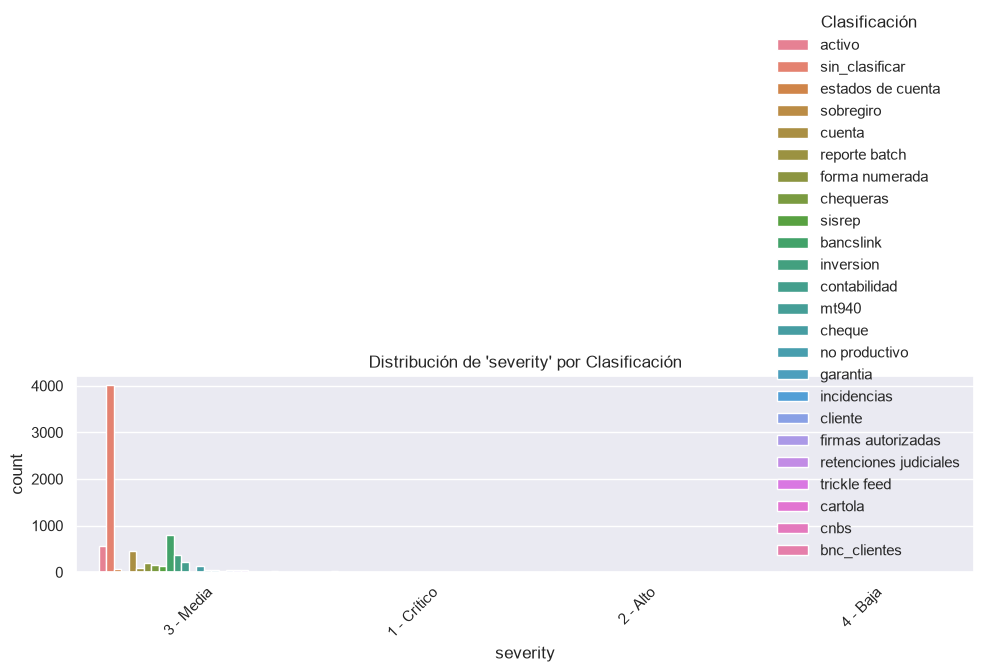

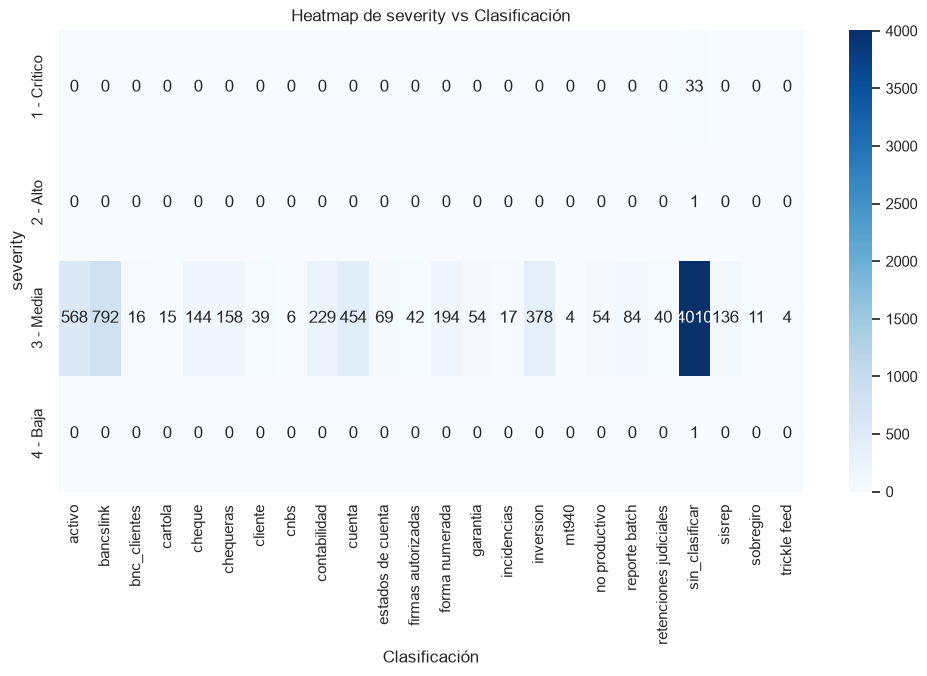


--- contact_type ---


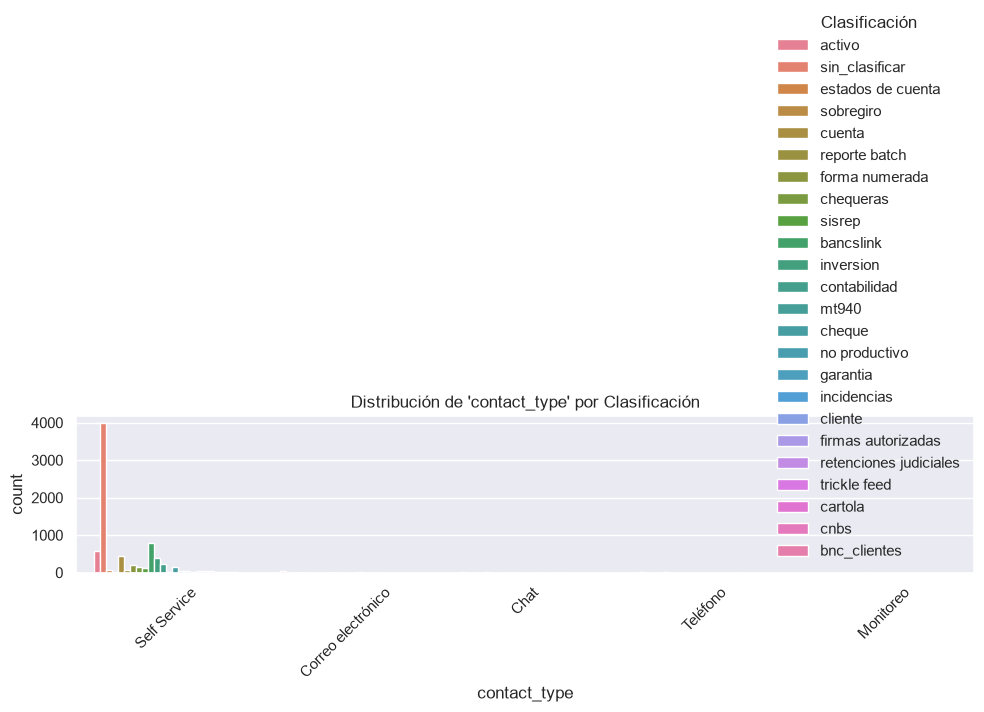

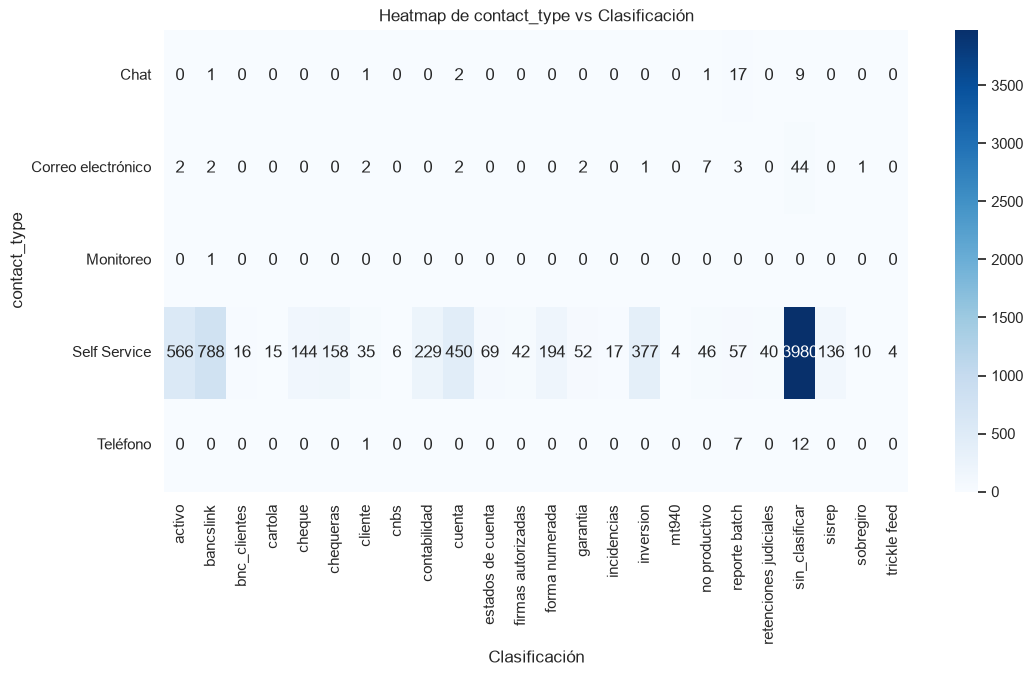


--- assignment_group ---


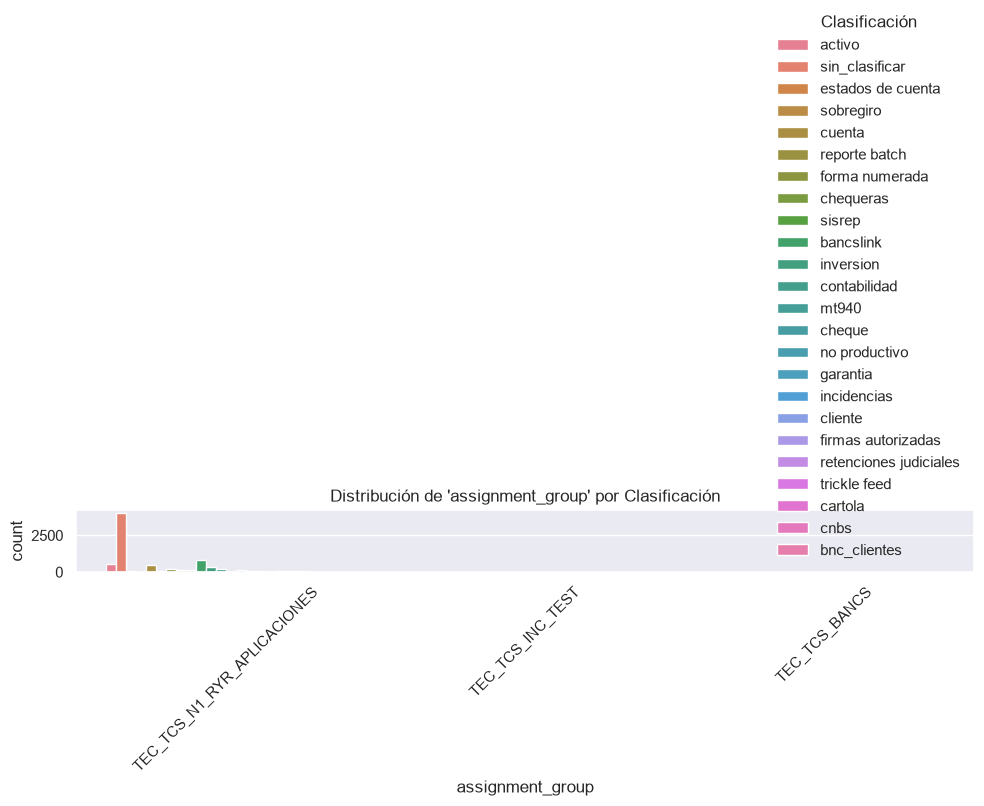

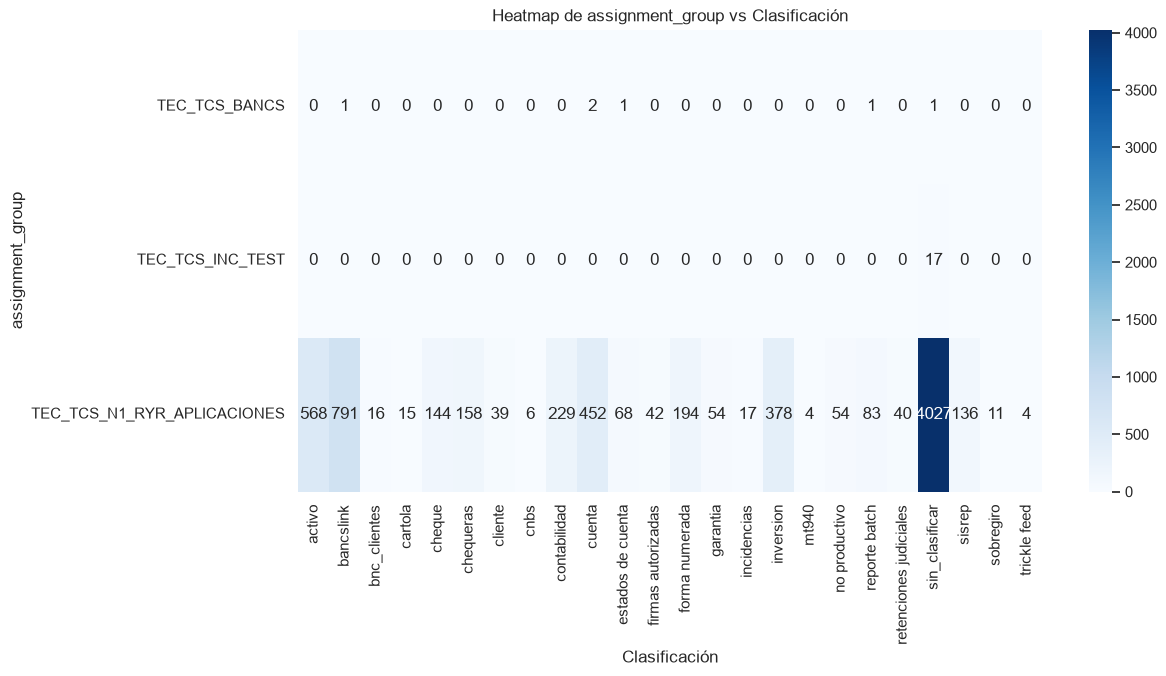


--- u_subcategory ---


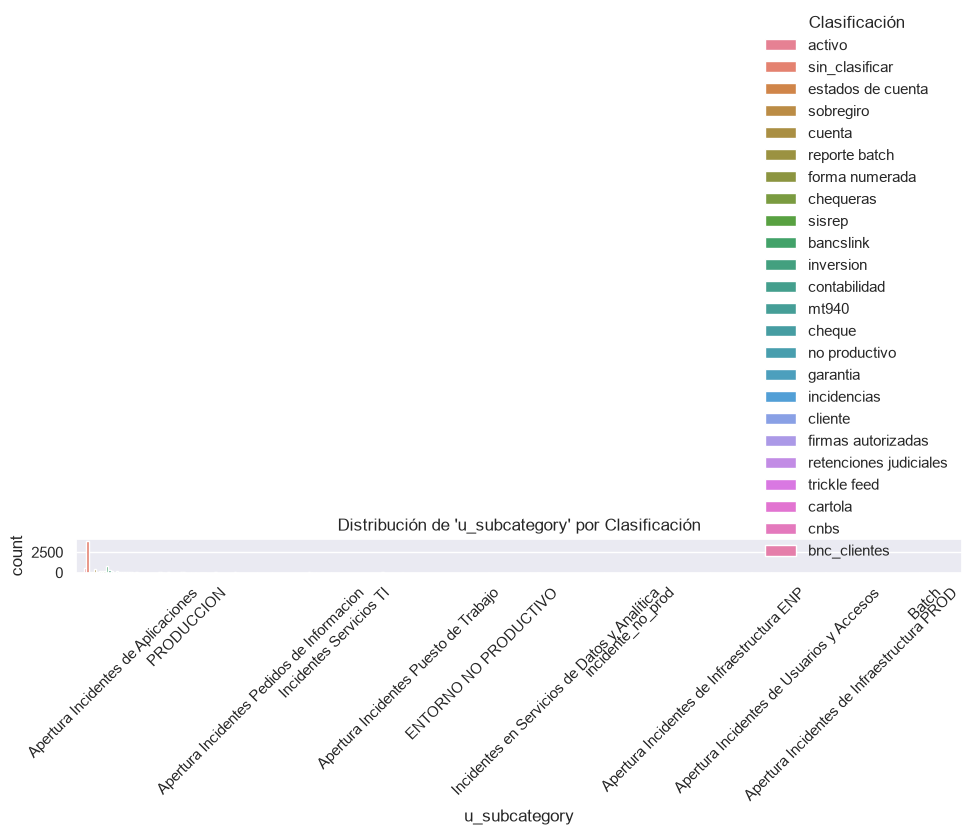

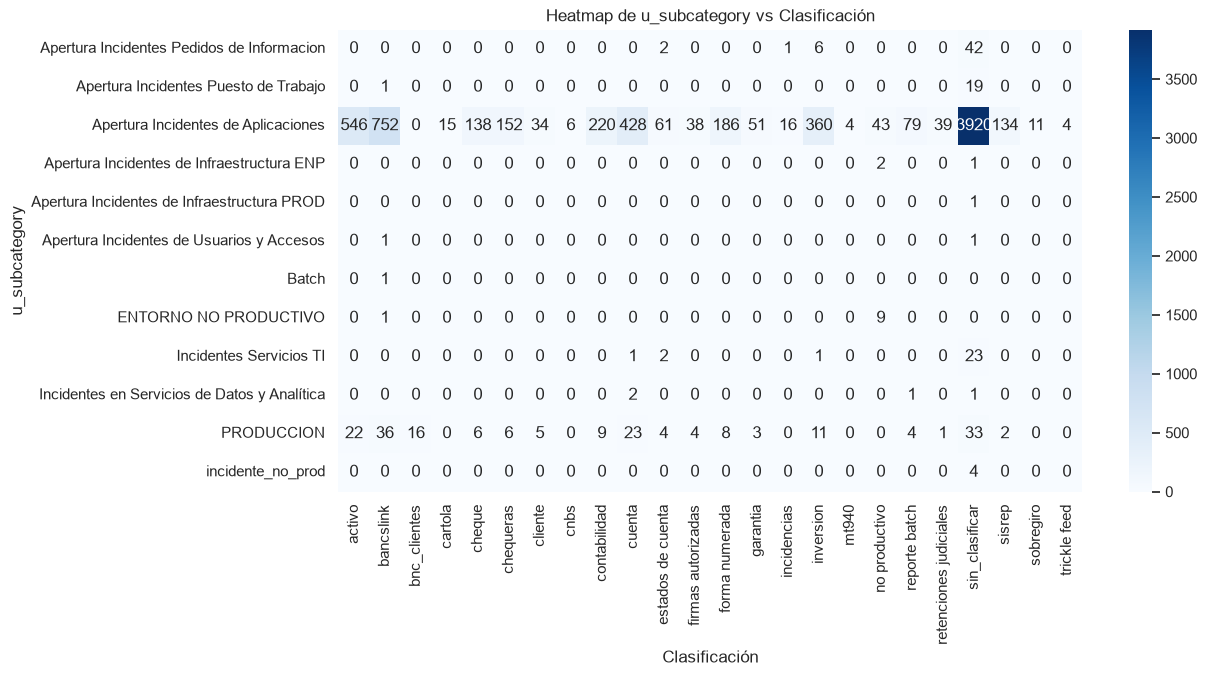


--- u_subcategory_2 ---


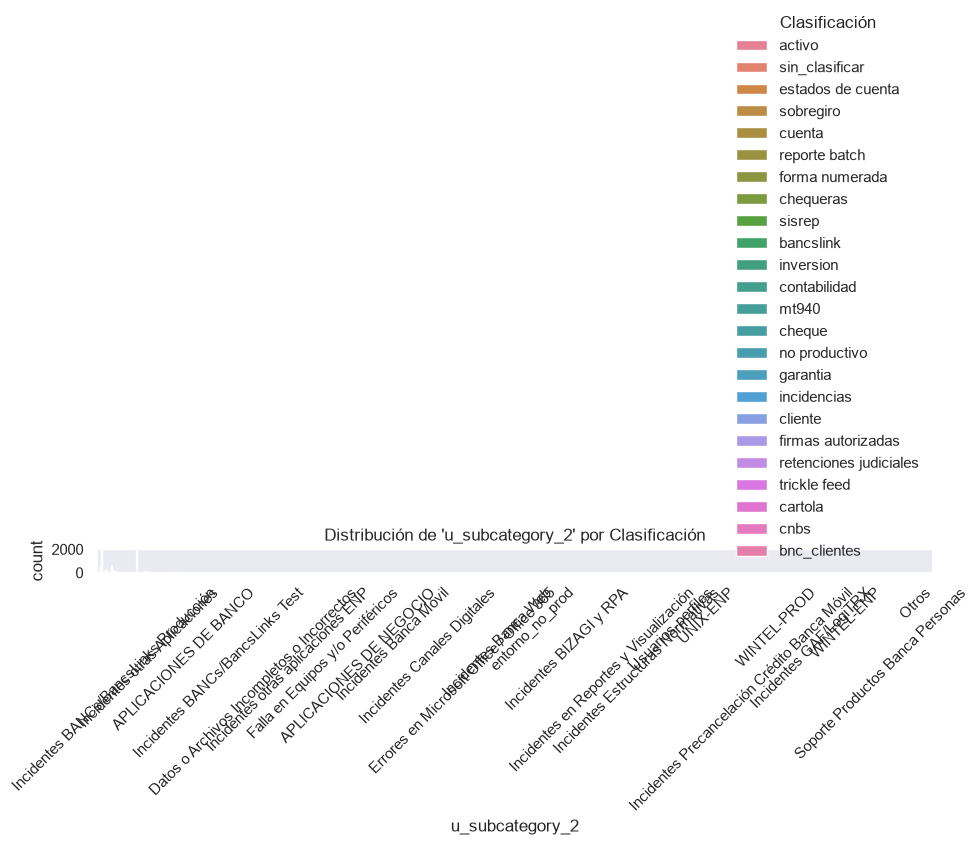

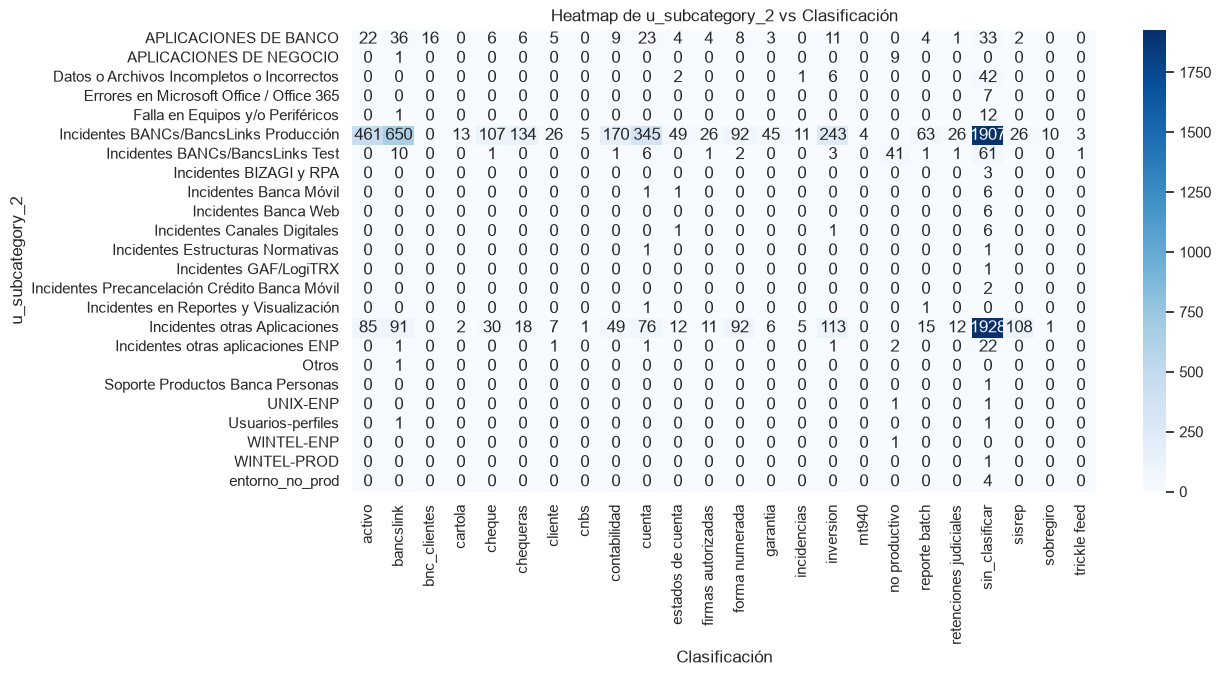

In [16]:
# Gráficos de barras apiladas y heatmaps para columnas categóricas relevantes
columnas_categoricas = [
    'priority', 'severity', 'contact_type', 'assignment_group', 'Origen', 'Ambiente',
    'u_subcategory', 'u_subcategory_2'
]

for col in columnas_categoricas:
    if col in df.columns and df[col].nunique() > 1 and df[col].nunique() < 25:
        print(f"\n--- {col} ---")
        # Gráfico de barras apiladas
        plt.figure(figsize=(10, 5))
        sns.countplot(data=df, x=col, hue='Clasificación', order=df[col].value_counts().index)
        plt.title(f"Distribución de '{col}' por Clasificación")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        # Heatmap de la tabla de contingencia
        tabla = pd.crosstab(df[col], df['Clasificación'])
        plt.figure(figsize=(12, 6))
        sns.heatmap(tabla, annot=True, fmt='d', cmap='Blues')
        plt.title(f"Heatmap de {col} vs Clasificación")
        plt.show()



Boxplot y ANOVA: business_duration vs Clasificación


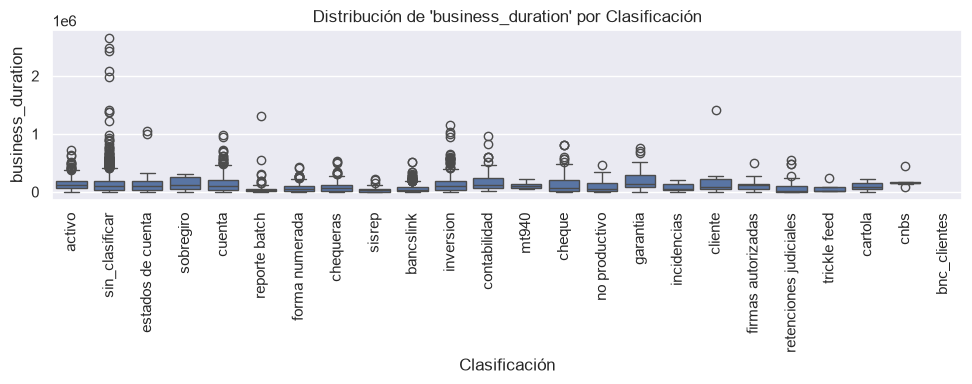

p-valor ANOVA: nan

Boxplot y ANOVA: reopen_count vs Clasificación


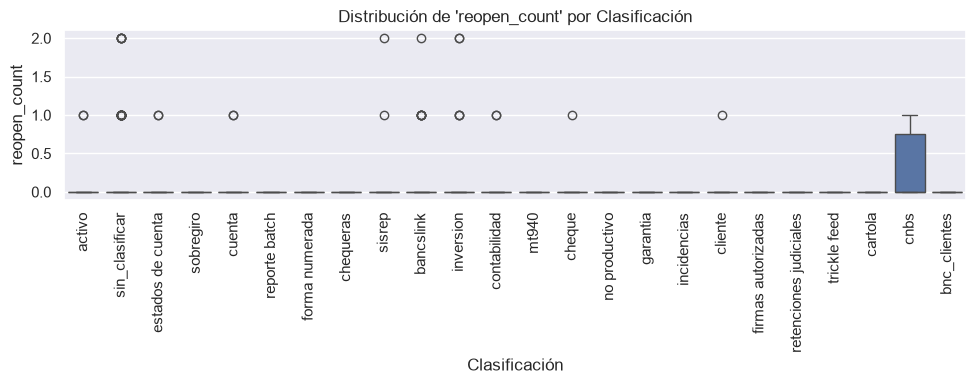

p-valor ANOVA: 0.0000


In [17]:
# 2. Variables numéricas vs. Clasificación (ANOVA y boxplots)
# Recomputar columnas_informativas sobre el df ya renombrado (sin 'Categoría')
columnas_informativas = [
    col for col in df.columns
    if df[col].nunique() > 1
    and df[col].nunique() < df.shape[0] * 0.9
    and not col.lower().startswith('id')
]

num_vars = [col for col in columnas_informativas if df[col].dtype in ['int64', 'float64']]
for col in num_vars:
    print(f"\nBoxplot y ANOVA: {col} vs Clasificación")
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x='Clasificación', y=col)
    plt.title(f"Distribución de '{col}' por Clasificación")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    # ANOVA solo si hay más de un grupo
    grupos = [g[1] for g in df.groupby('Clasificación')[col] if len(g[1]) > 1]
    if len(grupos) > 1:
        stat, p = f_oneway(*grupos)
        print(f"p-valor ANOVA: {p:.4f}")


## 5. Preparación de Datos para Modelado

In [18]:
# Cargar stopwords ANTES de limpiar_texto para poder usarlas en la limpieza
nltk.download('stopwords', quiet=True)
spanish_stopwords = set(stopwords.words('spanish'))
print(f"✓ Stopwords cargadas: {len(spanish_stopwords)} palabras")


✓ Stopwords cargadas: 313 palabras


In [19]:
# Unificar texto relevante para análisis de similitud
df['texto_unificado'] = (
    df['short_description'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['u_subcategory'].fillna('') + ' ' +
    df['u_subcategory_2'].fillna('')
)
# Guardar copia del texto crudo ANTES de limpiar (para análisis de duplicados)
df['texto_unificado_raw'] = df['texto_unificado']


In [20]:
# ── Análisis de duplicados exactos en texto_unificado (PRE-limpieza) ──────────
# Usa texto_unificado_raw para que sea robusto sin importar el orden de ejecución.

dup_mask_raw = df['texto_unificado_raw'].duplicated(keep=False)
df_dups_raw = df[dup_mask_raw].copy()

print(f"Tickets con texto_unificado duplicado (crudo): {dup_mask_raw.sum()}  "
      f"({dup_mask_raw.mean():.1%} del total)")
print(f"Textos únicos que se repiten: {df_dups_raw['texto_unificado_raw'].nunique()}")

# Tabla de frecuencias: cuántas veces se repite cada texto y sus clasificaciones
resumen_dups = (
    df_dups_raw
    .groupby('texto_unificado_raw', as_index=False)
    .agg(
        n_tickets       = ('number', 'count'),
        clasificaciones = ('Clasificación', lambda x: ', '.join(sorted(x.unique()))),
        n_clases        = ('Clasificación', 'nunique'),
        ejemplos        = ('number', lambda x: ', '.join(x.head(4).astype(str)))
    )
    .rename(columns={'texto_unificado_raw': 'texto_unificado'})
    .sort_values('n_tickets', ascending=False)
    .reset_index(drop=True)
)

print("\nTop 20 textos más repetidos:")
with pd.option_context('display.max_colwidth', 80):
    display(resumen_dups.head(20))

# Duplicados con clasificaciones distintas (ambigüedad real)
ambiguos = resumen_dups[resumen_dups['n_clases'] > 1]
print(f"\nTextos duplicados con DISTINTAS clasificaciones (ambigüedad): {len(ambiguos)}")
if len(ambiguos):
    with pd.option_context('display.max_colwidth', 80):
        display(ambiguos.head(20))


Tickets con texto_unificado duplicado (crudo): 173  (2.3% del total)
Textos únicos que se repiten: 65

Top 20 textos más repetidos:


,texto_unificado,n_tickets,clasificaciones,n_clases,ejemplos
0,ERROR EN SALDOS MONETARIOS AHORROS ESTIMADOS FAVOR SU AYUDA CON LA CORREC ER...,8,contabilidad,1,"INC0427508, INC0434815, INC0427056, INC0427458"
1,Estimados; Por favor su apoyo con la revisión de las operaciones que se regi...,7,sin_clasificar,1,"INC0148831, INC0149865, INC0156630, INC0141189"
2,ESTIMADOS FAVOR SU AYUDA CON LA CORREC ERROR EN SALDOS DE LAS CTA DETALLADAS...,6,sin_clasificar,1,"INC0139358, INC0068696, INC0037870, INC0053554"
3,RE-PAGO INVALIDO Estimados por favor su ayuda con la regularización de la op...,5,sin_clasificar,1,"INC0222064, INC0193333, INC0266327, INC0222084"
4,"ERROR PROHIBICION CHEQUES BANCSLINK Estimados su ayuda, aplicativo Bancslink...",5,bancslink,1,"INC0428072, INC0336487, INC0427204, INC0331364"
5,ERROR AL VALIDAR RETENCIONES JUDICIALES Estimados favor su ayuda error al va...,5,retenciones judiciales,1,"INC0318409, INC0327352, INC0313754, INC0319150"
6,REPAGO INVALIDO REPAGO INVALIDO Apertura Incidentes de Aplicaciones Incident...,4,"activo, sin_clasificar",2,"INC0637434, INC0664028, INC0363736, INC0190105"
7,CORRECCION DE SALDOS MONETARIOS AH ESTIMADOS FAVOR SU AYUDA CON LA CORREC ER...,4,"contabilidad, sin_clasificar",2,"INC0208764, INC0344178, INC0365782, INC0271135"
8,ERROR AL VALIDAR RETENCIONES JUDICIALES Estimados favor su ayuda error al va...,4,retenciones judiciales,1,"INC0337893, INC0329607, INC0320612, INC0336481"
9,PENDIENTE FACTURACIÓN GTOS. BANCARIOS Estimados el 03/02/2025 el cliente sol...,4,estados de cuenta,1,"INC0330873, INC0330877, INC0330875, INC0330869"



Textos duplicados con DISTINTAS clasificaciones (ambigüedad): 14


,texto_unificado,n_tickets,clasificaciones,n_clases,ejemplos
6,REPAGO INVALIDO REPAGO INVALIDO Apertura Incidentes de Aplicaciones Incident...,4,"activo, sin_clasificar",2,"INC0637434, INC0664028, INC0363736, INC0190105"
7,CORRECCION DE SALDOS MONETARIOS AH ESTIMADOS FAVOR SU AYUDA CON LA CORREC ER...,4,"contabilidad, sin_clasificar",2,"INC0208764, INC0344178, INC0365782, INC0271135"
12,2301: CODIGO DE PRIORIDAD DE DESEMBOLSO DEL REPAGO INVALIDO \t\t\t\t\t\t\t\t...,3,"activo, sin_clasificar",2,"INC0268003, INC0269833, INC0423066"
13,ESTIMADOS FAVOR SU AYUDA CON LA CORREC ERROR EN SALDOS DE LAS CTA DETALLADAS...,3,"contabilidad, sin_clasificar",2,"INC0684927, INC0706296, INC0510595"
15,CORRECCION DE SALDOS MONETARIOS CTES ESTIMADOS FAVOR SU AYUDA CON LA CORREC ...,3,"contabilidad, sin_clasificar",2,"INC0335396, INC0291309, INC0208795"
26,CORRECCION DE SALDOS MONETARIOS AHORROS ESTIMADOS FAVOR SU AYUDA CON LA CORR...,2,"contabilidad, sin_clasificar",2,"INC0242273, INC0287484"
30,2301: CÓDIGO DE PRIORIDAD DE DESEMBOLSO DEL REPAGO INVÁLIDO 2301: CÓDIGO DE ...,2,"activo, sin_clasificar",2,"INC0273822, INC0324752"
31,2301: CODIGO DE PRIORIDAD DE DESEMBOLSO DEL REPAGO INVALIDO \t\t\t\t\t\t\t\t...,2,"activo, sin_clasificar",2,"INC0438495, INC0118228"
35,ERROR EN SALDO MONETARIOS AHORROS ESTIMADOS FAVOR SU AYUDA CON LA CORREC ERR...,2,"contabilidad, sin_clasificar",2,"INC0251813, INC0329055"
41,"Estimados, por favor su apoyo no me permite cambiar la razón social aparece ...",2,"cuenta, sin_clasificar",2,"INC0411614, INC0423910"


In [21]:
# ── IDs de tickets ambiguos (ninguna clasificación es "sin_clasificar") ───────
textos_ambiguos_reales = resumen_dups[
    (resumen_dups['n_clases'] > 1) &
    (~resumen_dups['clasificaciones'].str.contains(r'\bsin_clasificar\b', na=False))
]['texto_unificado'].tolist()

ids_ambiguos = (
    df[df['texto_unificado_raw'].isin(textos_ambiguos_reales)]['number']
    .sort_values()
    .reset_index(drop=True)
)

print(f"Total IDs para revisión: {len(ids_ambiguos)}")
display(ids_ambiguos.to_frame())


Total IDs para revisión: 0


,number


In [22]:
# ── Contenido completo de los tickets ambiguos para revisión ──────────────────
cols_mostrar = ['number', 'texto_unificado_raw', 'Clasificación']
# Agrega columnas extra si existen en df
for col_extra in ['short_description', 'description', 'Subcategoría', 'category', 'subcategory']:
    if col_extra in df.columns and col_extra not in cols_mostrar:
        cols_mostrar.append(col_extra)

df_revision = (
    df[df['number'].isin(ids_ambiguos)]
    [cols_mostrar]
    .sort_values('number')
    .reset_index(drop=True)
)

print(f"Tickets para revisión: {len(df_revision)}")
with pd.option_context('display.max_colwidth', 200, 'display.max_rows', None):
    display(df_revision)


Tickets para revisión: 0


,number,texto_unificado_raw,Clasificación,short_description,description,category


In [23]:
mapa_mayoritario = {}
for texto in textos_ambiguos_reales:
    conteo = (
        df[df['texto_unificado_raw'] == texto]['Clasificación']
        .value_counts()
    )
    mapa_mayoritario[texto] = conteo.idxmax()

mask_ambiguos = df['texto_unificado_raw'].isin(textos_ambiguos_reales)
df.loc[mask_ambiguos, 'Clasificación'] = df.loc[mask_ambiguos, 'texto_unificado_raw'].map(mapa_mayoritario)

print(f"Tickets corregidos: {mask_ambiguos.sum()}")
print("\nClasificación asignada por texto ambiguo:")
for texto, clase in mapa_mayoritario.items():
    print(f" → '{texto[:80]}...' ► {clase}")

verificacion = (
    df[mask_ambiguos]
    .groupby('texto_unificado_raw')['Clasificación']
    .nunique()
)
assert (verificacion == 1).all(), "¡Aún quedan textos con múltiples clases!"
print(f"\n✓ Verificación OK: todos los textos ambiguos tienen ahora una única clasificación.")


Tickets corregidos: 0

Clasificación asignada por texto ambiguo:

✓ Verificación OK: todos los textos ambiguos tienen ahora una única clasificación.


In [24]:
# ── Deduplicación de textos repetidos ────────────────────────────────────────
# Tras resolver ambigüedades, todos los duplicados ya tienen una única
# clasificación. Se elimina la redundancia conservando un representante
# por texto para evitar data leakage (mismo ticket en train y test).

filas_antes_dedup = len(df)
df = df.drop_duplicates(subset='texto_unificado_raw', keep='first').reset_index(drop=True)
filas_eliminadas_dedup = filas_antes_dedup - len(df)

print(f"Filas antes de deduplicar : {filas_antes_dedup}")
print(f"Filas eliminadas (duplicados): {filas_eliminadas_dedup}  "
      f"({filas_eliminadas_dedup / filas_antes_dedup:.1%} del total)")
print(f"Filas tras deduplicar     : {len(df)}")
print(f"\nDistribución de clases tras deduplicar:")
print(df['Clasificación'].value_counts().to_string())


Filas antes de deduplicar : 7553
Filas eliminadas (duplicados): 108  (1.4% del total)
Filas tras deduplicar     : 7445

Distribución de clases tras deduplicar:
Clasificación
sin_clasificar            3994
bancslink                  782
activo                     563
cuenta                     450
inversion                  378
contabilidad               207
forma numerada             193
chequeras                  158
cheque                     142
sisrep                     135
reporte batch               84
estados de cuenta           66
garantia                    54
no productivo               53
firmas autorizadas          42
cliente                     39
retenciones judiciales      33
incidencias                 17
cartola                     15
bnc_clientes                15
sobregiro                   11
cnbs                         6
mt940                        4
trickle feed                 4


In [25]:
def limpiar_texto(texto):
    if pd.isnull(texto):
        return ""
    texto = str(texto).lower()
    # Normalizar acentos y caracteres especiales
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    # Eliminar caracteres no alfanuméricos (excepto espacios)
    texto = re.sub(r'[^a-zA-Z0-9\s]', ' ', texto)
    # Eliminar tokens puramente numéricos (códigos, fechas, horas, IDs)
    texto = re.sub(r'\b\d+\b', ' ', texto)
    # Eliminar tokens alfanuméricos que sean mayormente números (ej: ws0067, v1, v2)
    texto = re.sub(r'\b[a-z]*\d+[a-z0-9]*\b', ' ', texto)
    # Eliminar tokens muy cortos (1-2 caracteres) que no aportan significado
    texto = re.sub(r'\b\w{1,2}\b', ' ', texto)
    # Normalizar espacios
    texto = re.sub(r'\s+', ' ', texto).strip()
    # Eliminar stopwords en español directamente en el texto
    tokens = texto.split()
    tokens = [t for t in tokens if t not in spanish_stopwords]
    return ' '.join(tokens)

df['texto_unificado'] = df['texto_unificado'].apply(limpiar_texto)

# Verificar mejora — mostrar muestra de textos limpios
print("Ejemplos de texto limpio (sin stopwords):")
for t in df['texto_unificado'].dropna().sample(5, random_state=42):
    print(" →", t[:120])


Ejemplos de texto limpio (sin stopwords):
 → quijije alcivar clara gilbertina massage display permite realizar cancelacion operacion massage display apertura inciden
 → error factura hilong oil service engineering ecuador cia ltda estimados gentil ayuda revision factura adjunta cliente in
 → web taller reporta valor vencido elo cliente encuentra dia cliente jumbo jumbo susana carmen cliente encuentra dia embar
 → error presentado bancs web teller existe descuadre tablas amortizacion ayuda revision urgente error presentado bancs web
 → favor apoyo eliminado cuenta ahorro transacional cliente campolo solines bruno antonio pudo completar transaccion favor 


In [26]:
# Separar tickets clasificados y no clasificados
df_clasificados = df[df['Clasificación'] != 'sin_clasificar'].copy()
df_no_clasificados = df[df['Clasificación'] == 'sin_clasificar'].copy()
print(f"Tickets clasificados: {df_clasificados.shape[0]}")
print(f"Tickets sin clasificar: {df_no_clasificados.shape[0]}")

Tickets clasificados: 3451
Tickets sin clasificar: 3994


## Vectorización 

In [27]:
# ===== PASO 1: VECTORIZACIÓN ÚNICA Y CONSISTENTE =====
# Las stopwords ya fueron eliminadas en limpiar_texto → no se repasan aquí
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Vectorizar datos clasificados
X_clasificados = vectorizer.fit_transform(df_clasificados['texto_unificado'])
y_clasificados = df_clasificados['Clasificación'].values

# Vectorizar datos sin clasificar (usando el MISMO vectorizer)
X_no_clasificados = vectorizer.transform(df_no_clasificados['texto_unificado'])

print("Distribución original de clases:", Counter(y_clasificados))
print(f"Matriz X_clasificados shape: {X_clasificados.shape}")
print(f"Vectorizer features: {vectorizer.get_feature_names_out().shape[0]}")


Distribución original de clases: Counter({'bancslink': 782, 'activo': 563, 'cuenta': 450, 'inversion': 378, 'contabilidad': 207, 'forma numerada': 193, 'chequeras': 158, 'cheque': 142, 'sisrep': 135, 'reporte batch': 84, 'estados de cuenta': 66, 'garantia': 54, 'no productivo': 53, 'firmas autorizadas': 42, 'cliente': 39, 'retenciones judiciales': 33, 'incidencias': 17, 'cartola': 15, 'bnc_clientes': 15, 'sobregiro': 11, 'cnbs': 6, 'mt940': 4, 'trickle feed': 4})
Matriz X_clasificados shape: (3451, 5000)
Vectorizer features: 5000


In [28]:
features = vectorizer.get_feature_names_out()
print(f"Total features: {len(features)}")
print("Primeras 20:", features[:20])
print("Últimas 20:", features[-20:])

Total features: 5000
Primeras 20: ['abono' 'abono abono' 'abono capital' 'abono credito' 'abonos'
 'abonos anticipados' 'abonos cliente' 'abril' 'abril enviar' 'acceder'
 'acceso' 'acceso bancslink' 'accion' 'accion vencimiento' 'account'
 'acepta' 'aceptar' 'acerca' 'acosta' 'acredita']
Últimas 20: ['vuelve' 'wang' 'web' 'web puede' 'web teller' 'webteller'
 'webteller dia' 'wilson' 'word' 'xmlns' 'xperta' 'xsl' 'xsl exmlt'
 'yyyymmdd' 'yyyymmdd anexo' 'zambrano' 'zip' 'zip sal' 'zona' 'zurita']


## Balanceo de clases

In [29]:
# ===== PASO 2: SPLIT ESTRATIFICADO (SIEMPRE ANTES del oversampling) =====
# Si se hace después, muestras duplicadas de train pueden aparecer en test → data leakage.

# Clases con un solo ejemplo no pueden estratificarse → van directo a train
conteo_clases_y = pd.Series(y_clasificados).value_counts()
clases_pocas = conteo_clases_y[conteo_clases_y < 2].index.tolist()

# Índices originales de df_clasificados para reconstruir df_test_base
idx_clasificados = df_clasificados.index.values

if clases_pocas:
    print(f"  Clases con solo 1 ejemplo (van directo a train): {clases_pocas}")
    mask_pocas = pd.Series(y_clasificados).isin(clases_pocas).values
    X_pocas, y_pocas = X_clasificados[mask_pocas], y_clasificados[mask_pocas]
    idx_pocas = idx_clasificados[mask_pocas]
    X_suf, y_suf = X_clasificados[~mask_pocas], y_clasificados[~mask_pocas]
    idx_suf = idx_clasificados[~mask_pocas]

    X_train_main, X_test, y_train_main, y_test, idx_train_main, idx_test_local = train_test_split(
        X_suf, y_suf, idx_suf, test_size=0.2, random_state=42, stratify=y_suf
    )
    X_train = vstack([X_train_main, X_pocas])
    y_train = np.concatenate([y_train_main, y_pocas])
else:
    X_train, X_test, y_train, y_test, _, idx_test_local = train_test_split(
        X_clasificados, y_clasificados, idx_clasificados,
        test_size=0.2, random_state=42, stratify=y_clasificados
    )

# DataFrame base del test set (columnas originales + etiqueta real)
df_test_base = df_clasificados.loc[idx_test_local].copy().reset_index(drop=True)
df_test_base['y_real'] = y_test

print(f"✓ Train set: {X_train.shape[0]} muestras")
print(f"✓ Test set:  {X_test.shape[0]} muestras (intacto, nunca modificado)")
print(f"✓ df_test_base: {df_test_base.shape[0]} filas")


✓ Train set: 2760 muestras
✓ Test set:  691 muestras (intacto, nunca modificado)
✓ df_test_base: 691 filas


In [30]:
# ===== PASO 3: OVERSAMPLING SOLO EN TRAIN =====
# Se usa RandomOverSampler en lugar de SMOTE porque:
#   - SMOTE interpola entre vecinos → genera vectores TF-IDF promedio sin sentido lingüístico
#   - RandomOverSampler duplica tickets reales → mantiene la semántica del texto original
#   - Para datos de texto dispersos (sparse), ROS es la opción más adecuada

ros = RandomOverSampler(random_state=42)
X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)

conteo_antes  = Counter(y_train)
conteo_despues = Counter(y_train_balanced)

print(f"✓ Balanceo con RandomOverSampler")
print(f"  Muestras antes:   {X_train.shape[0]}")
print(f"  Muestras después: {X_train_balanced.shape[0]}")
print(f"\nDistribución después del balanceo ({len(conteo_despues)} clases, todas igualadas):")
print(conteo_despues)


✓ Balanceo con RandomOverSampler
  Muestras antes:   2760
  Muestras después: 14398

Distribución después del balanceo (23 clases, todas igualadas):
Counter({'bancslink': 626, 'inversion': 626, 'activo': 626, 'estados de cuenta': 626, 'cuenta': 626, 'reporte batch': 626, 'chequeras': 626, 'sobregiro': 626, 'sisrep': 626, 'garantia': 626, 'no productivo': 626, 'contabilidad': 626, 'forma numerada': 626, 'bnc_clientes': 626, 'cheque': 626, 'cliente': 626, 'firmas autorizadas': 626, 'cnbs': 626, 'retenciones judiciales': 626, 'cartola': 626, 'incidencias': 626, 'trickle feed': 626, 'mt940': 626})


## KNN

### Método del codo

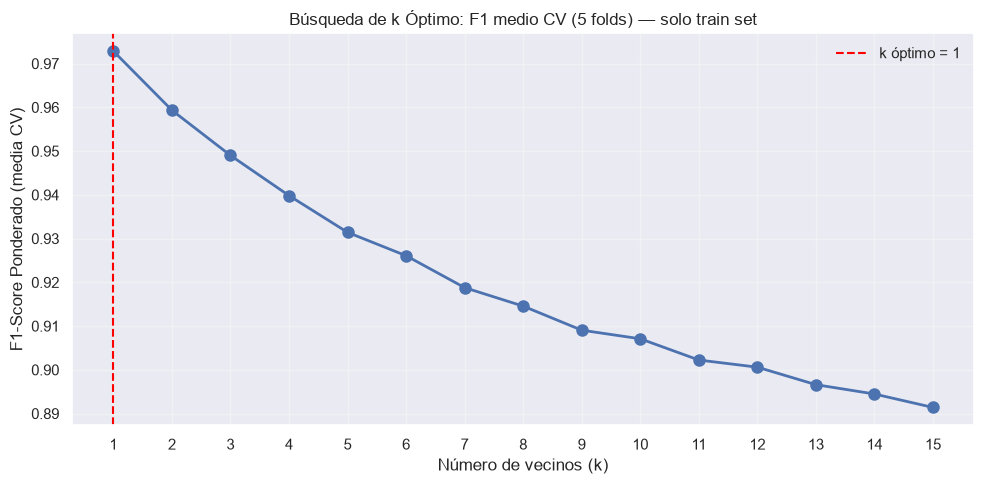


✓ k óptimo encontrado: 1
  F1-Score medio CV (train): 0.9728
  X_test no fue utilizado en este paso.


In [31]:
# ===== PASO 4: BÚSQUEDA DE k ÓPTIMO CON CROSS-VALIDATION =====
# Se evalúa con StratifiedKFold sobre X_train_balanced — X_test NO se toca aquí.
# Cada fold actúa como validación interna; el test set queda reservado para evaluación final.

k_range = range(1, 16)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    fold_f1 = []
    for train_idx, val_idx in cv.split(X_train_balanced, y_train_balanced):
        X_fold_train, y_fold_train = X_train_balanced[train_idx], y_train_balanced[train_idx]
        X_fold_val,   y_fold_val   = X_train_balanced[val_idx],   y_train_balanced[val_idx]
        knn.fit(X_fold_train, y_fold_train)
        y_fold_pred = knn.predict(X_fold_val)
        fold_f1.append(f1_score(y_fold_val, y_fold_pred, average='weighted', zero_division=0))
    f1_scores.append(np.mean(fold_f1))

k_optimo_idx = np.argmax(f1_scores)
k_optimo = list(k_range)[k_optimo_idx]

plt.figure(figsize=(10, 5))
plt.plot(k_range, f1_scores, marker='o', linewidth=2, markersize=8)
plt.axvline(x=k_optimo, color='red', linestyle='--', label=f'k óptimo = {k_optimo}')
plt.title('Búsqueda de k Óptimo: F1 medio CV (5 folds) — solo train set')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('F1-Score Ponderado (media CV)')
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ k óptimo encontrado: {k_optimo}")
print(f"  F1-Score medio CV (train): {max(f1_scores):.4f}")
print(f"  X_test no fue utilizado en este paso.")


In [32]:
# ===== PASO 5: ENTRENAMIENTO FINAL CON k ÓPTIMO =====
# Entrenar SOLO con datos balanceados de TRAIN
knn_final = KNeighborsClassifier(n_neighbors=k_optimo, metric='cosine')
knn_final.fit(X_train_balanced, y_train_balanced)

print(f"✓ Modelo KNN entrenado con k={k_optimo}")
print(f"  Datos de entrenamiento: {X_train_balanced.shape[0]} muestras")

# Clasificar los tickets no clasificados
y_pred_no_clasificados = knn_final.predict(X_no_clasificados)
df_no_clasificados['Clasificación_predicha'] = y_pred_no_clasificados

print(f"\n✓ Clasificados {df_no_clasificados.shape[0]} tickets sin clasificar")
print('\nEjemplos de tickets no clasificados y su predicción:')
display(df_no_clasificados[['texto_unificado', 'Clasificación_predicha']].head(10))

✓ Modelo KNN entrenado con k=1
  Datos de entrenamiento: 14398 muestras

✓ Clasificados 3994 tickets sin clasificar

Ejemplos de tickets no clasificados y su predicción:


,texto_unificado,Clasificación_predicha
4,gentil ayuda siguiente caso clienta mayra jime...,chequeras
5,error cuenta historico plataforma permite desc...,bancslink
7,validacion pago credito estimados favor valida...,activo
9,coinciden valores pago credito ayuda favor cli...,activo
10,cliente maria sol salinas representante asocia...,cuenta
11,regresar cheque devuelto aplicativo bancs esti...,cheque
12,revision procesador contable bancs satelite mu...,cuenta
13,error dos inversiones devolucion total estimad...,inversion
14,diferencia saldo contable disponible estimados...,sobregiro
15,error cuenta salta inactiva portal movimientos...,bancslink


In [33]:
# ===== PASO 6: EVALUACIÓN EN TEST SET (sin data leakage) =====
# Predecir en TEST SET (datos que el modelo NUNCA vio)
y_pred_test = knn_final.predict(X_test)

# Calcular métricas robustas
accuracy = accuracy_score(y_test, y_pred_test)
precision_weighted = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
recall_weighted = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
f1_weighted = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)

print("\n" + "="*60)
print("EVALUACIÓN EN TEST SET (Datos nuevos)")
print("="*60)
print(f"Accuracy:              {accuracy:.4f}")
print(f"Precision (ponderado): {precision_weighted:.4f}")
print(f"Recall (ponderado):    {recall_weighted:.4f}")
print(f"F1-Score (ponderado):  {f1_weighted:.4f}")

print("="*60)
print("REPORTE DE CLASIFICACIÓN (Por clase):")
print(classification_report(y_test, y_pred_test, zero_division=0))



EVALUACIÓN EN TEST SET (Datos nuevos)
Accuracy:              0.7004
Precision (ponderado): 0.7060
Recall (ponderado):    0.7004
F1-Score (ponderado):  0.7007
REPORTE DE CLASIFICACIÓN (Por clase):
                        precision    recall  f1-score   support

                activo       0.90      0.88      0.89       113
             bancslink       0.75      0.70      0.72       156
          bnc_clientes       1.00      1.00      1.00         3
               cartola       0.50      1.00      0.67         3
                cheque       0.46      0.61      0.52        28
             chequeras       0.69      0.69      0.69        32
               cliente       0.17      0.12      0.14         8
                  cnbs       1.00      1.00      1.00         1
          contabilidad       0.90      0.85      0.88        41
                cuenta       0.60      0.51      0.55        90
     estados de cuenta       0.67      0.62      0.64        13
    firmas autorizadas       0.64 

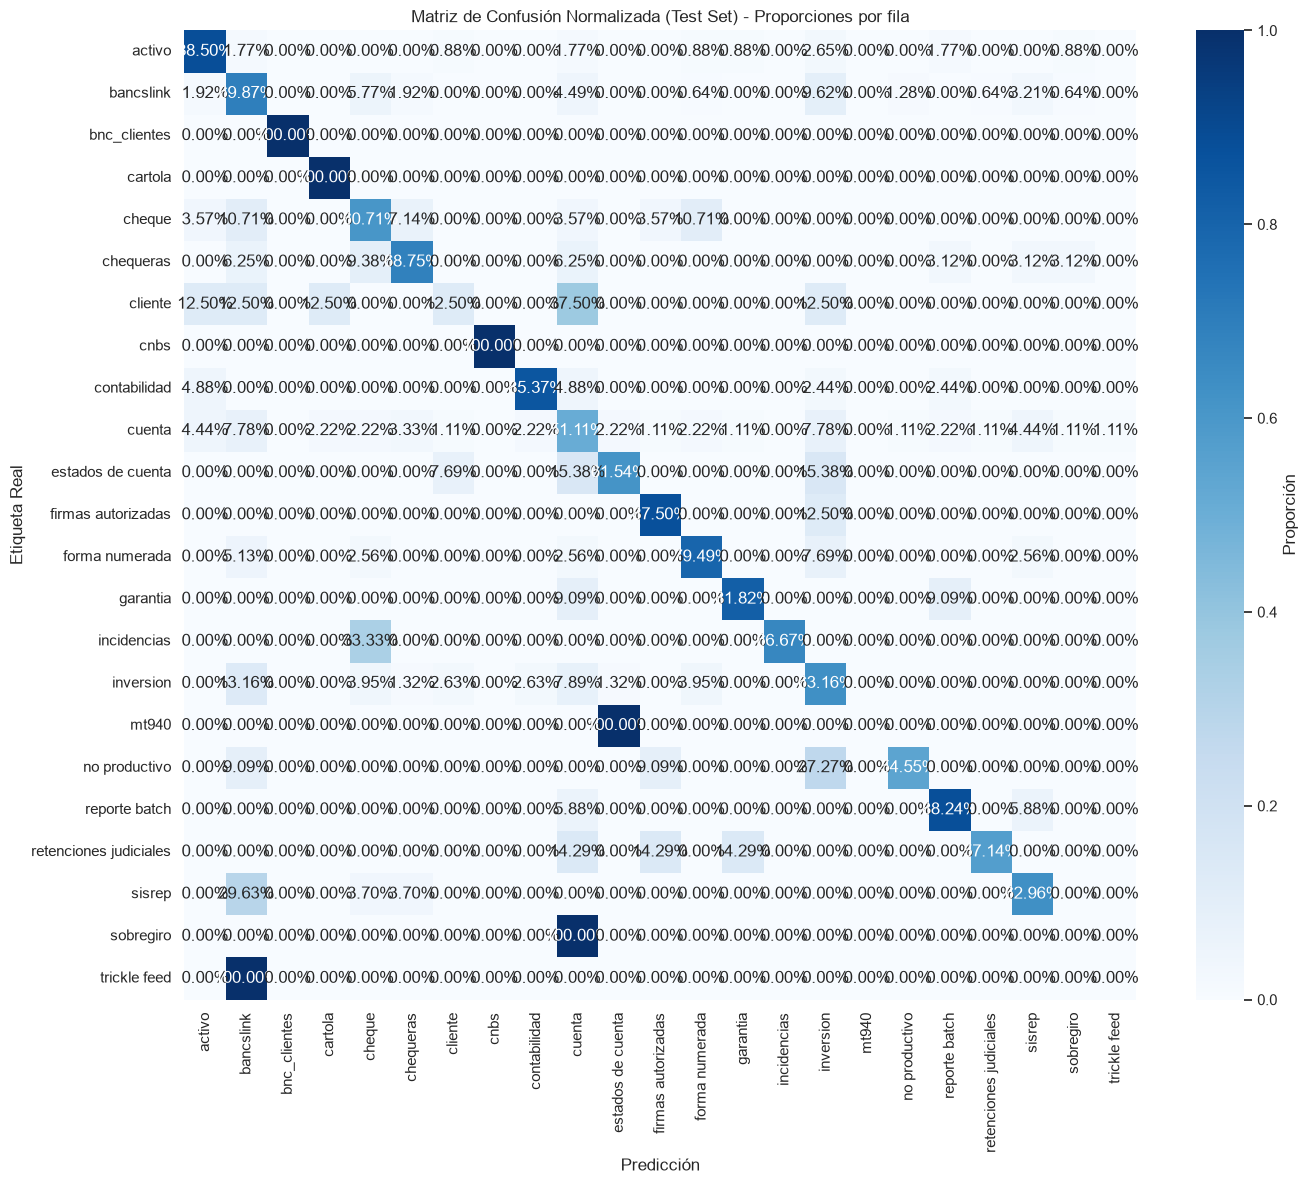

In [34]:
# Visualizar matriz de confusión normalizada
labels = sorted(list(set(list(y_test) + list(y_pred_test))))
cm = confusion_matrix(y_test, y_pred_test)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Proporción'})
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión Normalizada (Test Set) - Proporciones por fila')
plt.tight_layout()
plt.show()


## Comparativa de Clasificadores

### Random Forest

In [35]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf_model.fit(X_train_balanced, y_train_balanced)

print("✓ Random Forest entrenado  (n_estimators=200)")


✓ Random Forest entrenado  (n_estimators=200)


### Logistic Regression

In [36]:
lr_model = LogisticRegression(C=1.0, max_iter=3000, random_state=42, solver='lbfgs')
lr_model.fit(X_train_balanced, y_train_balanced)

print("✓ Logistic Regression entrenada  (C=1.0)")


✓ Logistic Regression entrenada  (C=1.0)


In [37]:

# ── Combinar los tres modelos y evaluar en test set ────────────────────────
modelos = {
    'KNN':                 knn_final,
    'Random Forest':       rf_model,
    'Logistic Regression': lr_model,
}

resultados = []
predicciones_modelos = {}
for nombre, modelo in modelos.items():
    y_pred_m = modelo.predict(X_test)
    predicciones_modelos[nombre] = y_pred_m
    resultados.append({
        'Modelo':    nombre,
        'Accuracy':  accuracy_score(y_test, y_pred_m),
        'F1-Score':  f1_score(y_test, y_pred_m, average='weighted', zero_division=0),
        'Precision': precision_score(y_test, y_pred_m, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test, y_pred_m, average='weighted', zero_division=0)
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')

print("=== Métricas comparativas (conjunto de prueba) ===\n")
print(df_resultados.round(4).to_string())

mejor = df_resultados['F1-Score'].idxmax()
print(f"\n► Mejor clasificador por F1-Score (weighted): {mejor}  "
      f"({df_resultados.loc[mejor, 'F1-Score']:.4f})")


=== Métricas comparativas (conjunto de prueba) ===

                     Accuracy  F1-Score  Precision  Recall
Modelo                                                    
KNN                    0.7004    0.7007     0.7060  0.7004
Random Forest          0.7786    0.7738     0.7899  0.7786
Logistic Regression    0.8162    0.8166     0.8248  0.8162

► Mejor clasificador por F1-Score (weighted): Logistic Regression  (0.8166)


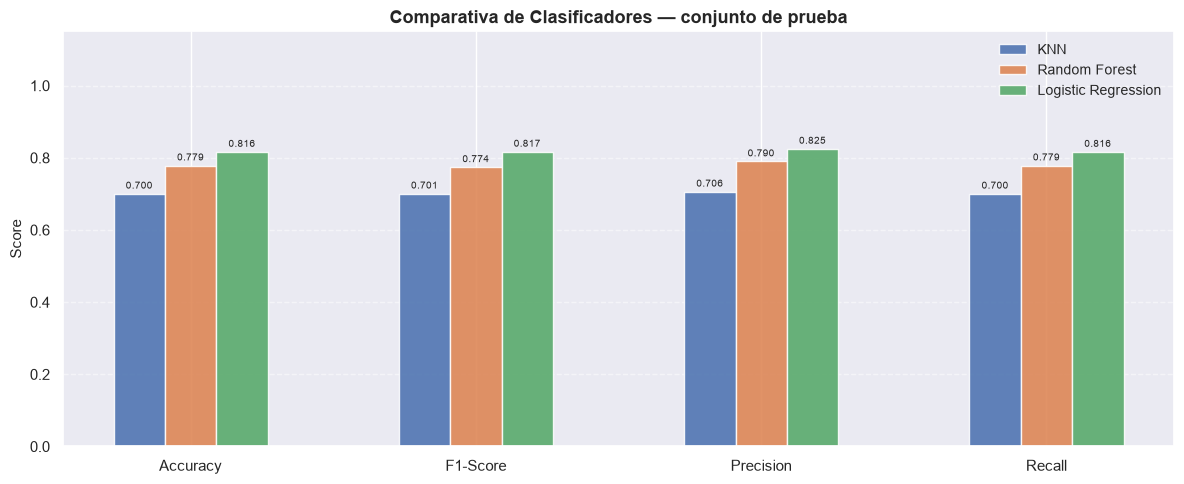

In [38]:
metricas = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
x = np.arange(len(metricas))
n_modelos = len(df_resultados)
ancho = 0.18
colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (nombre, row) in enumerate(df_resultados.iterrows()):
    valores = [row[m] for m in metricas]
    barras = ax.bar(x + i * ancho, valores, ancho, label=nombre, color=colores[i], alpha=0.88)
    for barra, val in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width() / 2,
                barra.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

offset_centro = (n_modelos - 1) * ancho / 2
ax.set_xticks(x + offset_centro)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Comparativa de Clasificadores — conjunto de prueba', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


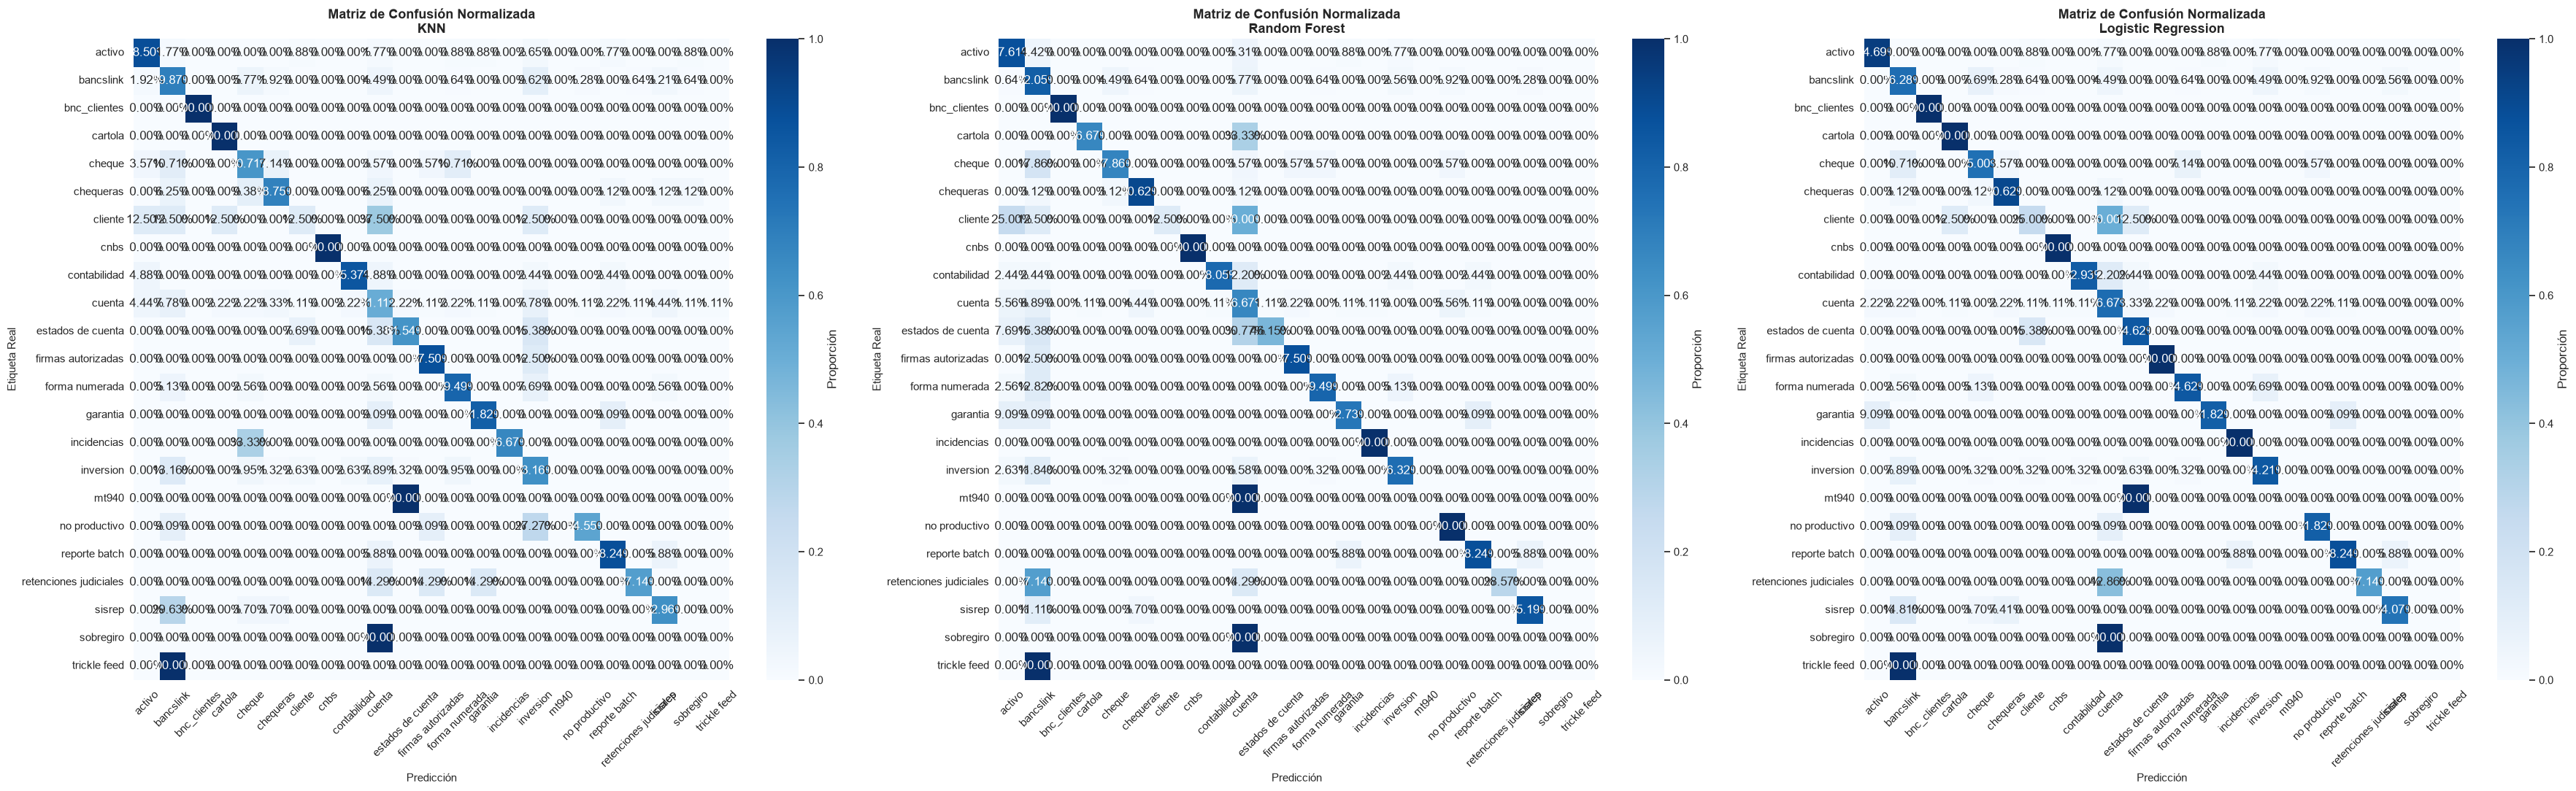

In [39]:
labels = sorted(list(set(list(y_test))))
fig, axes = plt.subplots(1, 3, figsize=(36, 11))

for ax, (nombre, y_pred_m) in zip(axes, predicciones_modelos.items()):
    cm = confusion_matrix(y_test, y_pred_m, labels=labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=True, fmt='.2%', cmap='Blues',
        xticklabels=labels, yticklabels=labels,
        cbar_kws={'label': 'Proporción'}, ax=ax
    )
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Etiqueta Real', fontsize=11)
    ax.set_title(f'Matriz de Confusión Normalizada\n{nombre}', fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


## Análisis de Errores

### Detalle de errores — Logistic Regression

Total de errores en test set: 127 de 691
Tasa de error: 18.38%
Accuracy: 0.8162

Top 15 confusiones más frecuentes:
                y_real        y_predicho  count
             bancslink            cheque     12
             bancslink         inversion      7
             bancslink            cuenta      7
             inversion         bancslink      6
          contabilidad            cuenta      5
               cliente            cuenta      4
             bancslink            sisrep      4
                sisrep         bancslink      4
             bancslink     no productivo      3
                cuenta estados de cuenta      3
        forma numerada         inversion      3
                cheque         bancslink      3
retenciones judiciales            cuenta      3
                cuenta            activo      2
                cuenta         bancslink      2

EJEMPLOS DE ERRORES (primeras 10 muestras mal clasificadas):


,number,short_description,texto_unificado,y_real,y_predicho
1,INC0275987,SISTEMA DE REPORTE DE INVERSIONES PARA TODOS LOS USUARIOS SALE VACIO,sistema reporte inversiones usuarios sale vacio sistema reporte inversiones usuarios sale vacio ...,bancslink,inversion
4,INC0374363,Error al intentar modificar país de nacionalidad del cliente desde CRM vía DPE (UMPClientes0078/...,error intentar modificar pais nacionalidad cliente crm via dpe momento actualizar nacionalidad c...,activo,cliente
8,INC0293130,INFORMACION MOTIVO O CONCEPTO DE RETENCION.,informacion motivo concepto retencion solicita informacion retencion rendimientos realizada loui...,inversion,estados de cuenta
17,INC0511828,8554: Transaccion solamente para cheques personales/corporativos,transaccion solamente cheques personales corporativos permite generar chequeras primera vez sale...,cheque,chequeras
22,INC0413221,RETENCIONES REALIZADAS A LOS CLIENTES NO REGISTRADAS EN BANCS,retenciones realizadas clientes registradas bancs estimados favor gentil ayuda revision clientes...,cliente,cuenta
31,INC0606662,SISREP - NO SE PUEDE SACAR EL LISTADO DE CHEQUE DEVUELTO,sisrep puede sacar listado cheque devuelto puede sacar listado cheque devuelto apertura incident...,sisrep,cheque
34,INC0436831,información incompleta en BTR_INCIDENCIAS_22082025,informacion incompleta btr incidencias estimados rfavor gentil ayuda carga completa archivo btr ...,reporte batch,incidencias
36,INC0551022,ERROR DE CANCELACION DE LAS CUENTA CORRIENTE,error cancelacion cuenta corriente buenas tardes estimados gentil ayuda cancelacion cuenta corri...,sobregiro,cuenta
47,INC0437488,CLIENTE PIDE ELIMINACION DE CARTOLA NO PERMITE PROCESO EN AGENCIA,cliente pide eliminacion cartola permite proceso agencia cliente pide eliminacion cartola permit...,cliente,cartola
65,INC0675257,Estimados su gentil ayuda al anular un cheque de emergencia no se genera la impresion de la sol...,estimados gentil ayuda anular cheque emergencia genera impresion solicitud anulacion estimados g...,forma numerada,cheque


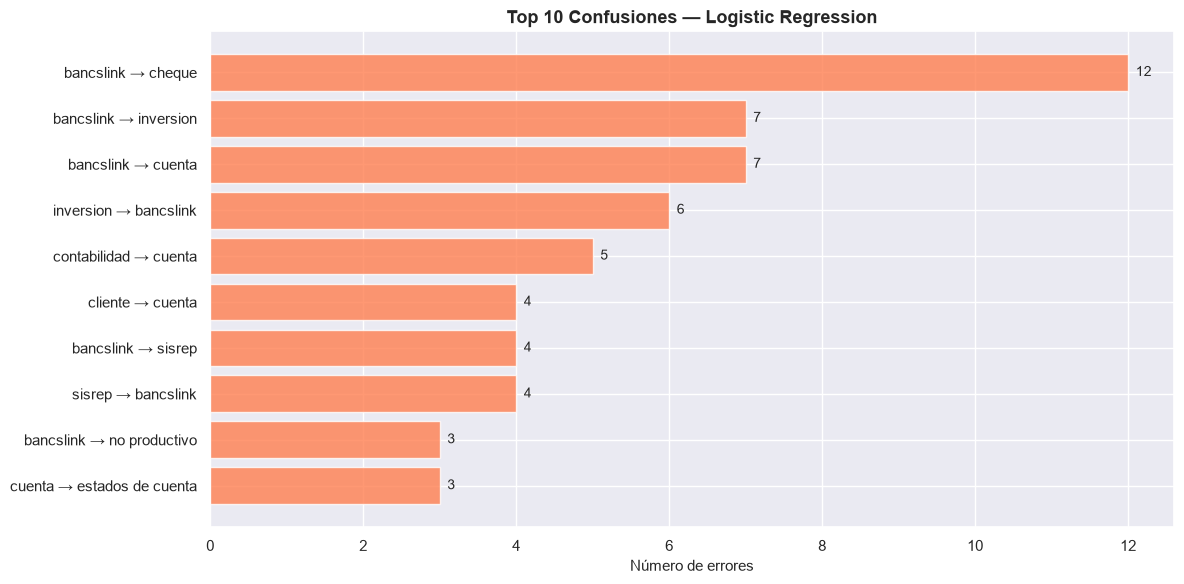

In [40]:
# ── Análisis detallado de errores — Logistic Regression ────────────────────

# Predecir en test set con Logistic Regression
y_pred_lr = lr_model.predict(X_test)

# Identificar muestras mal clasificadas
indices_errores = np.where(y_test != y_pred_lr)[0]
df_errores = df_test_base.iloc[indices_errores].copy()
df_errores['y_predicho'] = y_pred_lr[indices_errores]
df_errores['es_error'] = True

print(f"Total de errores en test set: {len(df_errores)} de {len(y_test)}")
print(f"Tasa de error: {len(df_errores) / len(y_test) * 100:.2f}%")
print(f"Accuracy: {1 - len(df_errores) / len(y_test):.4f}\n")

# Matriz de confusión de errores
print("Top 15 confusiones más frecuentes:")
confusiones = df_errores.groupby(['y_real', 'y_predicho']).size().reset_index(name='count')
confusiones = confusiones.sort_values('count', ascending=False).head(15)
print(confusiones.to_string(index=False))

# Mostrar ejemplos de errores por tipo
print("\n" + "="*80)
print("EJEMPLOS DE ERRORES (primeras 10 muestras mal clasificadas):")
print("="*80)

cols_error = [c for c in ['number', 'short_description', 'texto_unificado', 'y_real', 'y_predicho'] 
              if c in df_errores.columns]
with pd.option_context('display.max_colwidth', 100, 'display.max_rows', None):
    display(df_errores[cols_error].head(10))

# Gráfico: clases más confundidas
fig, ax = plt.subplots(figsize=(12, 6))
confusiones_top = confusiones.head(10)
barras = ax.barh(range(len(confusiones_top)), confusiones_top['count'], color='coral', alpha=0.8)
ax.set_yticks(range(len(confusiones_top)))
labels_y = [f"{row['y_real']} → {row['y_predicho']}" 
            for _, row in confusiones_top.iterrows()]
ax.set_yticklabels(labels_y)
ax.set_xlabel('Número de errores', fontsize=11)
ax.set_title('Top 10 Confusiones — Logistic Regression', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for barra, val in zip(barras, confusiones_top['count']):
    ax.text(val + 0.1, barra.get_y() + barra.get_height()/2, str(int(val)), 
            va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [41]:
# Tickets que presentan confusión (errores de clasificación en test)
# Usa df_errores generado en la celda de análisis de errores.

if 'df_errores' not in globals():
    raise ValueError("No existe 'df_errores'. Ejecuta primero la celda de análisis de errores.")

# Crear identificador de ticket si no existe la columna 'number'
if 'number' not in df_errores.columns:
    df_errores = df_errores.copy()
    df_errores['number'] = df_errores.index.astype(str)

print(f"Total de tickets con confusión: {len(df_errores)}")

# 1) Resumen por tipo de confusión (real -> predicho) con IDs de tickets
resumen_confusiones_tickets = (
    df_errores.groupby(['y_real', 'y_predicho'], as_index=False)
    .agg(
        total_tickets=('number', 'count'),
        tickets=('number', lambda x: ', '.join(x.astype(str).head(30)))
    )
    .sort_values('total_tickets', ascending=False)
)

print("\nTop confusiones con tickets asociados:")
display(resumen_confusiones_tickets)


Total de tickets con confusión: 127

Top confusiones con tickets asociados:


,y_real,y_predicho,total_tickets,tickets
4,bancslink,cheque,12,"INC0397596, INC0521632, INC0307907, INC0405716..."
9,bancslink,inversion,7,"INC0275987, INC0504669, INC0285398, INC0305635..."
7,bancslink,cuenta,7,"INC0364221, INC0276997, INC0357451, INC0349087..."
44,inversion,bancslink,6,"INC0286270, INC0040245, INC0136940, INC0096100..."
22,contabilidad,cuenta,5,"INC0304299, INC0395027, INC0394511, INC0303069..."
...,...,...,...,...
49,inversion,forma numerada,1,INC0608295
53,reporte batch,incidencias,1,INC0436831
54,reporte batch,sisrep,1,INC0166384
57,sisrep,cheque,1,INC0606662


In [42]:
# Exportar a CSV el resumen y/o detalle de tickets con confusión

fecha_hoy = pd.Timestamp.today().strftime("%Y-%m-%d")
carpeta_output = 'Resultados'
os.makedirs(carpeta_output, exist_ok=True)

# 1) Resumen de confusiones (si existe)
if 'resumen_confusiones_tickets' in globals():
    ruta_resumen = os.path.join(carpeta_output, f"resumen_confusiones_tickets_{fecha_hoy}.csv")
    resumen_confusiones_tickets.to_csv(ruta_resumen, index=False, encoding='utf-8-sig')
    print(f"✓ Resumen exportado: {ruta_resumen} ({len(resumen_confusiones_tickets)} filas)")

# 2) Detalle de tickets confundidos (si existe)
if 'tickets_confundidos' in globals():
    ruta_detalle = os.path.join(carpeta_output, f"tickets_confundidos_{fecha_hoy}.csv")
    tickets_confundidos.to_csv(ruta_detalle, index=False, encoding='utf-8-sig')
    print(f"✓ Detalle exportado: {ruta_detalle} ({len(tickets_confundidos)} filas)")
elif 'df_errores' in globals():
    cols_detalle = [c for c in ['number', 'short_description', 'texto_unificado', 'y_real', 'y_predicho'] if c in df_errores.columns]
    detalle_tmp = df_errores[cols_detalle].sort_values(['y_real', 'y_predicho', 'number']).reset_index(drop=True)
    ruta_detalle = os.path.join(carpeta_output, f"tickets_confundidos_{fecha_hoy}.csv")
    detalle_tmp.to_csv(ruta_detalle, index=False, encoding='utf-8-sig')
    print(f"✓ Detalle exportado (desde df_errores): {ruta_detalle} ({len(detalle_tmp)} filas)")

✓ Resumen exportado: Resultados\resumen_confusiones_tickets_2026-07-22.csv (61 filas)
✓ Detalle exportado (desde df_errores): Resultados\tickets_confundidos_2026-07-22.csv (127 filas)


## Generación de csv tickets ya clasificados tras algoritmo

In [43]:

# ── Usar el mejor clasificador para predecir tickets no clasificados ──────────
mejor_modelo = modelos[mejor]
y_pred_final = mejor_modelo.predict(X_no_clasificados)

# ── Obtener confianza de la predicción ────────────────────────────────────────
# NOTA: LinearSVC no tiene predict_proba → se usa decision_function + softmax,
#       pero esos valores NO son probabilidades calibradas (son distancias al hiperplano).
#       Por eso se usa un umbral más bajo (0.10) cuando el modelo es LinearSVC.
if hasattr(mejor_modelo, 'predict_proba'):
    proba_matrix = mejor_modelo.predict_proba(X_no_clasificados)
    confianza = proba_matrix.max(axis=1)
    umbral_revision = 0.40
    tipo_confianza = 'probabilidad calibrada'
else:
    # Softmax sobre decision_function — no es probabilidad real, solo aproximación relativa
    scores = mejor_modelo.decision_function(X_no_clasificados)
    exp_scores = np.exp(scores - scores.max(axis=1, keepdims=True))
    proba_matrix = exp_scores / exp_scores.sum(axis=1, keepdims=True)
    confianza = proba_matrix.max(axis=1)
    umbral_revision = 0.10   # umbral ajustado para scores softmax de LinearSVC
    tipo_confianza = 'softmax(decision_function) — no calibrada'

# ── Construir DataFrame resultado ─────────────────────────────────────────────
cols_visibles = [c for c in ['number', 'short_description', 'description',
                              'u_subcategory', 'u_subcategory_2', 'texto_unificado',
                              'Clasificación']
                 if c in df_no_clasificados.columns]

df_resultado = df_no_clasificados[cols_visibles].copy()
df_resultado['Clasificación_predicha'] = y_pred_final
df_resultado['Confianza'] = np.round(confianza, 4)
df_resultado['Requiere_revision'] = confianza < umbral_revision
df_resultado['Modelo_usado'] = mejor

print(f"Modelo usado: {mejor}  |  Tipo de confianza: {tipo_confianza}")
print(f"Umbral de revisión aplicado: {umbral_revision}")
print(f"\nTotal de tickets clasificados: {len(df_resultado)}")
print(f"\nDistribución de predicciones:")
print(df_resultado['Clasificación_predicha'].value_counts().to_string())
print(f"\nTickets con baja confianza (< {umbral_revision}): {df_resultado['Requiere_revision'].sum()} "
      f"({df_resultado['Requiere_revision'].mean():.1%} del total)")


Modelo usado: Logistic Regression  |  Tipo de confianza: probabilidad calibrada
Umbral de revisión aplicado: 0.4

Total de tickets clasificados: 3994

Distribución de predicciones:
Clasificación_predicha
activo                    1137
bancslink                 1038
cuenta                     639
cheque                     233
contabilidad               164
chequeras                  137
forma numerada             133
inversion                  131
estados de cuenta           87
sisrep                      58
no productivo               53
reporte batch               45
garantia                    39
cliente                     32
firmas autorizadas          28
sobregiro                   13
incidencias                 11
cartola                     11
retenciones judiciales       4
bnc_clientes                 1

Tickets con baja confianza (< 0.4): 1090 (27.3% del total)


In [44]:
display(df_resultado)

,number,short_description,description,u_subcategory,u_subcategory_2,texto_unificado,Clasificación,Clasificación_predicha,Confianza,Requiere_revision,Modelo_usado
4,INC0756601,su gentil ayuda con el siguiente caso la clien...,su gentil ayuda con el siguiente caso la clien...,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,gentil ayuda siguiente caso clienta mayra jime...,sin_clasificar,chequeras,0.9313,False,Logistic Regression
5,INC0754937,Error Estado de Cuenta Histórico,Plataforma no permite descargar estado de cuen...,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,error cuenta historico plataforma permite desc...,sin_clasificar,cuenta,0.5457,False,Logistic Regression
7,INC0756747,VALIDACION DE PAGO DE CREDITO,"Estimados, por favor su validación si el pago ...",Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,validacion pago credito estimados favor valida...,sin_clasificar,activo,0.5159,False,Logistic Regression
9,INC0755311,No coinciden valores por pago de crédito,Su ayuda por favor cliente Pedro Barre con ci....,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,coinciden valores pago credito ayuda favor cli...,sin_clasificar,activo,0.9251,False,Logistic Regression
10,INC0746474,LA CLIENTE MARIA SOL SALINAS REPRESENTANTE DE ...,LA CLIENTE MARIA SOL SALINAS REPRESENTANTE DE ...,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,cliente maria sol salinas representante asocia...,sin_clasificar,cuenta,0.1532,True,Logistic Regression
...,...,...,...,...,...,...,...,...,...,...,...
7425,INC0963657,no imprime desde el bancslink,no se envía la impresión desde el aplicativo b...,PRODUCCION,APLICACIONES DE BANCO,imprime bancslink envia impresion aplicativo b...,sin_clasificar,bancslink,0.8017,False,Logistic Regression
7428,INC0963757,documentos de inversiones y bancs desconfigura...,documentos de inversiones y bancs desconfigura...,PRODUCCION,APLICACIONES DE BANCO,documentos inversiones bancs desconfigurados i...,sin_clasificar,inversion,0.4437,False,Logistic Regression
7432,INC0964149,ERROR AL MOMENTO DE GENERAR PAGARES PROCESO MA...,ERROR AL MOMENTO DE GENERAR PAGARES PROCESO MA...,PRODUCCION,APLICACIONES DE BANCO,error momento generar pagares proceso manual t...,sin_clasificar,bancslink,0.2336,True,Logistic Regression
7442,INC0965468,HABILITAR ACCESOS EN BANCS - GONZAGA SALTO ART...,"favor su ayuda habilitar los accesos en Bancs,...",PRODUCCION,APLICACIONES DE BANCO,habilitar accesos bancs gonzaga salto arturo p...,sin_clasificar,bancslink,0.1491,True,Logistic Regression


✓ CSV exportado: Resultados\tickets_clasificados_Logistic_Regression_2026-07-22.csv
  Filas: 3994  |  Columnas: ['number', 'short_description', 'description', 'u_subcategory', 'u_subcategory_2', 'texto_unificado', 'Clasificación', 'Clasificación_predicha', 'Confianza', 'Requiere_revision', 'Modelo_usado']

  Alta confianza (≥ 0.4): 2904 tickets
  Requiere revisión  (< 0.4): 1090 tickets


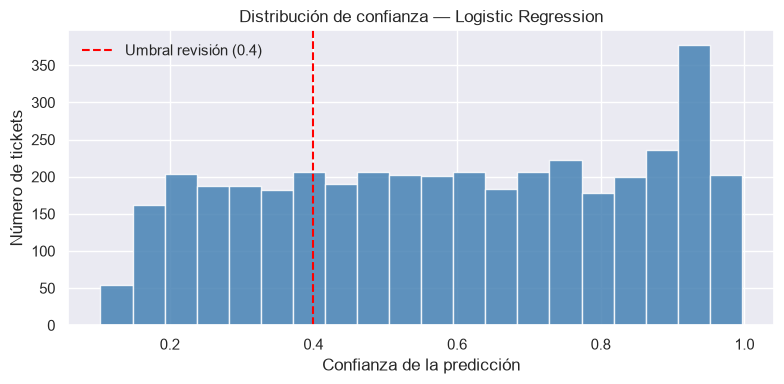

In [45]:
from datetime import datetime

# Carpeta output/ al mismo nivel que Data/ (un nivel arriba de Analisis/)
fecha_hoy = datetime.now().strftime("%Y-%m-%d")
nombre_modelo_csv = mejor.replace(" ", "_")
nombre_archivo = f"tickets_clasificados_{nombre_modelo_csv}_{fecha_hoy}.csv"

carpeta_output = 'Resultados'
os.makedirs(carpeta_output, exist_ok=True)

ruta_salida = os.path.normpath(os.path.join(carpeta_output, nombre_archivo))
df_resultado.to_csv(ruta_salida, index=False, encoding='utf-8-sig', sep=';')

print(f"✓ CSV exportado: {ruta_salida}")
print(f"  Filas: {len(df_resultado)}  |  Columnas: {list(df_resultado.columns)}")
print(f"\n  Alta confianza (≥ {umbral_revision}): {(~df_resultado['Requiere_revision']).sum()} tickets")
print(f"  Requiere revisión  (< {umbral_revision}): {df_resultado['Requiere_revision'].sum()} tickets")

# ── Histograma de confianza ───────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(df_resultado['Confianza'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(umbral_revision, color='red', linestyle='--', linewidth=1.5,
            label=f'Umbral revisión ({umbral_revision})')
plt.xlabel('Confianza de la predicción')
plt.ylabel('Número de tickets')
plt.title(f'Distribución de confianza — {mejor}')
plt.legend()
plt.tight_layout()
plt.show()


In [46]:
# ── Combinar tickets clasificados originales + tickets reclasificados ──────────

# 1. DataFrame de tickets clasificados (originales, sin cambios)
df_clasificados_final = df_clasificados[['number', 'short_description', 'description',
                                          'u_subcategory', 'u_subcategory_2', 
                                          'texto_unificado', 'Clasificación']].copy()
df_clasificados_final['Fuente'] = 'Original_Clasificado'
df_clasificados_final['Confianza'] = 1.0

# 2. DataFrame de tickets reclasificados (que eran sin_clasificar)
df_reclasificados = df_no_clasificados[['number', 'short_description', 'description',
                                         'u_subcategory', 'u_subcategory_2',
                                         'texto_unificado']].copy()
df_reclasificados['Clasificación'] = y_pred_final
df_reclasificados['Fuente'] = 'Reclasificado_IA'
df_reclasificados['Confianza'] = confianza

# 3. Combinar ambos DataFrames
df_completo = pd.concat([df_clasificados_final, df_reclasificados], 
                         ignore_index=True, sort=False)

# 4. Ordenar por número de ticket
df_completo = df_completo.sort_values('number').reset_index(drop=True)

# 5. Exportar CSV completo
fecha_hoy = datetime.now().strftime("%Y-%m-%d")
nombre_archivo_completo = f"tickets_clasificados_completo_{mejor.replace(' ', '_')}_{fecha_hoy}.csv"
carpeta_output = 'Resultados'
os.makedirs(carpeta_output, exist_ok=True)

ruta_salida_completa = os.path.normpath(os.path.join(carpeta_output, nombre_archivo_completo))
df_completo.to_csv(ruta_salida_completa, index=False, encoding='utf-8-sig')

print(f"✓ CSV COMPLETO exportado: {ruta_salida_completa}")
print(f"  Total de tickets: {len(df_completo)}")
print(f"  - Clasificados originales: {len(df_clasificados_final)}")
print(f"  - Reclasificados (sin_clasificar → IA): {len(df_reclasificados)}")
print(f"\nDistribución final de clasificaciones:") 
print(df_completo['Clasificación'].value_counts().to_string())
print(f"\nColumnas del CSV: {list(df_completo.columns)}")

✓ CSV COMPLETO exportado: Resultados\tickets_clasificados_completo_Logistic_Regression_2026-07-22.csv
  Total de tickets: 7445
  - Clasificados originales: 3451
  - Reclasificados (sin_clasificar → IA): 3994

Distribución final de clasificaciones:
Clasificación
bancslink                 1820
activo                    1700
cuenta                    1089
inversion                  509
cheque                     375
contabilidad               371
forma numerada             326
chequeras                  295
sisrep                     193
estados de cuenta          153
reporte batch              129
no productivo              106
garantia                    93
cliente                     71
firmas autorizadas          70
retenciones judiciales      37
incidencias                 28
cartola                     26
sobregiro                   24
bnc_clientes                16
cnbs                         6
trickle feed                 4
mt940                        4

Columnas del CSV: ['numb

In [47]:
# ── Persistencia del modelo y vectorizer ─────────────────────────────────────
# Se guardan juntos en la carpeta 'modelo/' para garantizar que la
# transformación TF-IDF sea idéntica al momento de inferencia futura.
nombre_modelo = mejor.replace(' ', '_')

carpeta_modelo = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'semisupervised_model'))
os.makedirs(carpeta_modelo, exist_ok=True)

ruta_modelo     = os.path.join(carpeta_modelo, f'modelo_{nombre_modelo}.joblib')
ruta_vectorizer = os.path.join(carpeta_modelo, 'vectorizer_tfidf.joblib')

joblib.dump(mejor_modelo, ruta_modelo)
joblib.dump(vectorizer,   ruta_vectorizer)

print(f"✓ Modelo guardado:     {ruta_modelo}")
print(f"✓ Vectorizer guardado: {ruta_vectorizer}")
print()
print("Para cargar y usar en otro script:")
print(f"  modelo     = joblib.load('modelo/modelo_{nombre_modelo}.joblib')")
print(f"  vectorizer = joblib.load('modelo/vectorizer_tfidf.joblib')")
print(f"  X_nuevo    = vectorizer.transform(textos_nuevos)")
print(f"  prediccion = modelo.predict(X_nuevo)")


✓ Modelo guardado:     z:\Deberes\Maestrías\Inteligencia Artificial Aplicada\Proyecto Integrador\Asignador\Incidentes\semisupervised_model\modelo_Logistic_Regression.joblib
✓ Vectorizer guardado: z:\Deberes\Maestrías\Inteligencia Artificial Aplicada\Proyecto Integrador\Asignador\Incidentes\semisupervised_model\vectorizer_tfidf.joblib

Para cargar y usar en otro script:
  modelo     = joblib.load('modelo/modelo_Logistic_Regression.joblib')
  vectorizer = joblib.load('modelo/vectorizer_tfidf.joblib')
  X_nuevo    = vectorizer.transform(textos_nuevos)
  prediccion = modelo.predict(X_nuevo)
